#  NBA Awards & Champion Predictor
## Прогнозирование наград НБА и чемпиона с помощью машинного обучения

---

> **О чём этот проект?**  
> Здесь собран полный пайплайн анализа данных и машинного обучения, направленный на одну цель:  
> **по статистике регулярного сезона предсказать победителей пяти наград НБА** (чемпион, MVP, DPOY, MIP, ROTY) **на сезон 2025–26**.  
>
> Ноутбук структурирован так, чтобы пройти путь от «сырых» данных до готовых вероятностей шаг за шагом.  
> Каждый шаг сопровождается подробным объяснением: что делается, зачем и как интерпретировать результат.

---

### Структура ноутбука

| # | Раздел | Краткое содержание |
|---|--------|--------------------|
| 1 | Загрузка и описание данных | Откуда данные, что в них содержится |
| 2 | Инженерия признаков | Создание дополнительных метрик и меток |
| 3 | Разведочный анализ (EDA) | Визуализация распределений, трендов, выбросов |
| 4 | Модели и валидация | Обучение 4 моделей, выбор лучшей |
| 5 | Прогнозы на 2025–26 | Топ-5 претендентов по каждой номинации |
| 6 | Итоги | Качество моделей и выводы |

---

**Технологический стек:** Python 3, pandas, scikit-learn, XGBoost, LightGBM, matplotlib, seaborn  
**Данные:** NBA API (nba_api) — официальная статистика НБА, сезоны 2013–14 - 2025–26


---
## Часть 1. Загрузка данных

### 1.1 Откуда берутся данные?

Данные собраны с помощью официальной Python-библиотеки **`nba_api`**, которая обращается напрямую к базе данных NBA. Это гарантирует точность и актуальность статистики.

Используются **два датасета**:

| Датасет | Что содержит | Временной охват   |
|---------|-------------|-------------------|
| `nba_players_2013_2026_full.csv` | Статистика каждого игрока за каждый сезон | 2013–14 - 2025–26 |
| `nba_teams_2013_2026_full.csv` | Статистика каждой команды за каждый сезон | 2013–14 - 2025–26 |

Каждый датасет разделён по **типу игр**: Regular Season и Playoffs.  
В дальнейшем для обучения моделей используется **только Regular Season** — именно регулярный сезон является основой для голосования за индивидуальные награды.

---

### 1.2 Код сбора данных (справочно — не нужно запускать повторно)

Данный блок кода показывает, как данные были собраны изначально.  
**Запускать его снова не нужно** — файлы CSV уже сохранены на диске.


In [2]:
# ──────────────────────────────────────────────────────────────────
# СПРАВОЧНЫЙ КОД: как были собраны данные (запускать не нужно)
# ──────────────────────────────────────────────────────────────────
# Библиотека nba_api обращается к серверам NBA и возвращает
# статистику в виде DataFrame. Мы перебираем сезоны и типы игр
# в цикле, делая паузу между запросами (time.sleep), чтобы не
# получить блокировку от сервера.

# import pandas as pd
# import time
# from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashteamstats
#
# seasons = [
#     '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19',
#     '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26'
# ]
# season_types = ['Regular Season', 'Playoffs']
#
# player_stats_list, team_stats_list = [], []
#
# for season in seasons:
#     for s_type in season_types:
#         player_info = leaguedashplayerstats.LeagueDashPlayerStats(
#             season=season, per_mode_detailed='PerGame', season_type_all_star=s_type)
#         df_players = player_info.get_data_frames()[0]
#         df_players['SEASON'], df_players['SEASON_TYPE'] = season, s_type
#         player_stats_list.append(df_players)
#         time.sleep(1.2)
#
#         team_info = leaguedashteamstats.LeagueDashTeamStats(
#             season=season, per_mode_detailed='PerGame', season_type_all_star=s_type)
#         df_teams = team_info.get_data_frames()[0]
#         df_teams['SEASON'], df_teams['SEASON_TYPE'] = season, s_type
#         team_stats_list.append(df_teams)
#         time.sleep(1.2)
#
# pd.concat(player_stats_list, ignore_index=True).to_csv('nba_players_2013_2026_full.csv', index=False)
# pd.concat(team_stats_list, ignore_index=True).to_csv('nba_teams_2013_2026_full.csv', index=False)
print("Этот блок — справочный, запускать не нужно.")


Этот блок — справочный, запускать не нужно.


---
### 1.3 Ключевые столбцы датасетов

Прежде чем загружать данные в Python, полезно понимать, какие переменные (признаки) в них есть.

#### Датасет игроков

| Группа | Столбцы | Что означает |
|--------|---------|-------------|
| Идентификаторы | `PLAYER_NAME`, `TEAM_ID`, `SEASON` | Имя, команда, сезон |
| Метаданные | `SEASON_TYPE`, `AGE`, `GP`, `MIN` | Тип игр, возраст, кол-во матчей, минуты за игру |
| Бросковая эффективность | `FG_PCT`, `FG3_PCT`, `FT_PCT` | % попаданий со средней, с трёхочковой, со штрафных |
| Базовая статистика | `PTS`, `REB`, `AST`, `STL`, `BLK`, `TOV` | Очки, подборы, передачи, перехваты, блоки, потери |
| Рейтинги | `PTS_RANK`, `AST_RANK`, `REB_RANK` | Позиция игрока по показателю в текущем сезоне |

#### Датасет команд

| Группа | Столбцы | Что означает |
|--------|---------|-------------|
| Идентификаторы | `TEAM_NAME`, `TEAM_ID`, `SEASON` | Название, ID, сезон |
| Результаты | `W`, `L`, `W_PCT` | Победы, поражения, процент побед |
| Статистика игры | `PTS`, `REB`, `AST`, `FG_PCT`, `PLUS_MINUS` | Аналогично игрокам, но на уровне команды |


---
## Часть 2. Загрузка данных и инженерия признаков

### 2.1 Импорт библиотек

Сначала подключаем все необходимые Python-библиотеки. Ниже — краткое описание роли каждой из них.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.linear_model import LogisticRegression  # логистическая регрессия
from sklearn.ensemble import RandomForestClassifier  # случайный лес
from xgboost import XGBClassifier                    # градиентный бустинг XGBoost
from lightgbm import LGBMClassifier                  # градиентный бустинг LightGBM

from sklearn.model_selection import (
    TimeSeriesSplit,       # кросс-валидация с учётом порядка времени
    GridSearchCV           # автоматический перебор гиперпараметров
)
from sklearn.preprocessing import StandardScaler  # нормализация признаков
from sklearn.metrics import (
    roc_auc_score,    # метрика AUC-ROC
    precision_score,  # точность (precision)
    roc_curve,        # кривая ROC
    accuracy_score,   # доля правильных ответов
    log_loss,         # логистическая функция потерь (ключевая метрика)
    brier_score_loss  # оценка качества вероятностей
)
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

plt.rcParams['figure.figsize'] = (10, 6)  # размер графиков по умолчанию
print("Все библиотеки загружены успешно.")


Все библиотеки загружены успешно.


---
### 2.2 Загрузка CSV-файлов

Загружаем оба файла с диска и сразу фильтруем: оставляем только строки с `SEASON_TYPE == 'Regular Season'`.

**Почему только Regular Season?**  
Голосование за индивидуальные награды NBA (MVP, DPOY и др.) происходит по итогам регулярного чемпионата, а не плей-офф. Статистика плей-офф будет полезна для других аналитических задач, но для обучения предсказательных моделей наград нам важна именно регулярка.


In [4]:
df_players = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_players_2013_2026_full.csv')
df_teams   = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_teams_2013_2026_full.csv')

# Оставляем только регулярный сезон
df_players = df_players[df_players['SEASON_TYPE'] == 'Regular Season'].copy()
df_teams   = df_teams[df_teams['SEASON_TYPE'] == 'Regular Season'].copy()

print(f"Игроки: {df_players.shape[0]} строк, {df_players.shape[1]} столбцов")
print(f"Команды: {df_teams.shape[0]} строк, {df_teams.shape[1]} столбцов")


Игроки: 6942 строк, 69 столбцов
Команды: 390 строк, 56 столбцов


---
### 2.3 Создание производных метрик

Официальная статистика NBA содержит сырые показатели. Для более точного описания игрока создадим два дополнительных признака, широко используемых в баскетбольной аналитике.

---

#### 2.3.1 True Shooting % (TS%)

**Что это?**  
Стандартный `FG_PCT` (процент попаданий) не учитывает, что трёхочковый бросок «стоит» больше, а штрафные бросаются из позиции с высоким шансом попасть. TS% исправляет это: он показывает эффективность игрока с учётом ценности каждого типа броска.

**Формула:**

$$TS\% = \frac{PTS}{2 \times (FGA + 0.44 \times FTA)}$$

- `PTS` — очки за игру  
- `FGA` — попытки с игры (двухочковые + трёхочковые)  
- `FTA` — попытки штрафных бросков  
- Коэффициент **0.44** — эмпирически установленная доля «владений», которую занимает одна попытка со штрафной линии

Чем выше TS%, тем эффективнее игрок завершает атаки в расчёте на одно владение.  
Среднее по НБА — около **56–57%**.


In [5]:
# True Shooting % — более точная оценка бросковой эффективности
# Числитель: очки игрока
# Знаменатель: «взвешенное» число атакующих действий
df_players['TS_PCT'] = df_players['PTS'] / (2 * (df_players['FGA'] + 0.44 * df_players['FTA']))

# Если FGA и FTA оба равны нулю — деление на 0 даёт бесконечность или NaN.
# Заменяем такие значения нулём (игрок не бросал — эффективность 0)
df_players['TS_PCT'] = df_players['TS_PCT'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("TS% рассчитан. Пример значений:")
print(df_players[['PLAYER_NAME', 'SEASON', 'PTS', 'FGA', 'FTA', 'TS_PCT']].head(5).to_string(index=False))


TS% рассчитан. Пример значений:
  PLAYER_NAME  SEASON  PTS  FGA  FTA   TS_PCT
     AJ Price 2013-14  1.6  1.6  0.1 0.486618
 Aaron Brooks 2013-14  9.0  8.1  1.3 0.518911
   Aaron Gray 2013-14  1.8  1.6  0.5 0.494505
Adonis Thomas 2013-14  2.3  2.3  0.2 0.481575
Al Harrington 2013-14  6.6  6.1  1.0 0.504587


---
#### 2.3.2 Usage Rate (USG%)

**Что это?**  
USG% (доля атак, в которых участвует игрок) показывает, насколько игрок вовлечён в атаку команды.  
Игрок с USG% = 30% «использует» 30% всех владений своей команды, пока он на площадке.

**Формула:**

$$USG\% = \frac{100 \times (FGA + 0.44 \times FTA + TOV) \times Tm\_MIN}{MIN \times (Tm\_FGA + 0.44 \times Tm\_FTA + Tm\_TOV)}$$

- `FGA`, `FTA`, `TOV` — показатели **игрока**  
- `Tm_FGA`, `Tm_FTA`, `Tm_TOV` — те же показатели для **всей команды**  
- `MIN` — минуты игрока; `Tm_MIN` — суммарные минуты команды  
- Деление на минуты нормализует: игрок на 35 минутах сравнивается с игроком на 20 минутах корректно

Для расчёта нужно «подтянуть» командную статистику к таблице игроков через `merge` по полям `TEAM_ID` и `SEASON` (аналог SQL JOIN).


In [6]:
# Шаг 1: Берём нужные столбцы из таблицы команд
team_cols = ['TEAM_ID', 'SEASON', 'MIN', 'FGA', 'FTA', 'TOV']
teams_subset = df_teams[team_cols].copy()
# Переименовываем, чтобы не было конфликта с колонками таблицы игроков
teams_subset.columns = ['TEAM_ID', 'SEASON', 'Tm_MIN', 'Tm_FGA', 'Tm_FTA', 'Tm_TOV']

# Шаг 2: Присоединяем командную статистику к каждому игроку
# how='left' означает: все строки игроков сохраняются, даже если команда не найдена
df_analysis = df_players.merge(teams_subset, on=['TEAM_ID', 'SEASON'], how='left')

# Шаг 3: Считаем USG% и записываем в исходную таблицу игроков
df_players['USG_PCT'] = 100 * (
    (df_analysis['FGA'] + 0.44 * df_analysis['FTA'] + df_analysis['TOV'])
    * df_analysis['Tm_MIN']
) / (
    df_analysis['MIN']
    * (df_analysis['Tm_FGA'] + 0.44 * df_analysis['Tm_FTA'] + df_analysis['Tm_TOV'])
)

print("USG% рассчитан.")
print(df_players[['PLAYER_NAME', 'SEASON', 'MIN', 'PTS', 'USG_PCT']].head(5).to_string(index=False))


USG% рассчитан.
  PLAYER_NAME  SEASON  MIN  PTS   USG_PCT
     AJ Price 2013-14  3.5  1.6 23.630272
 Aaron Brooks 2013-14 21.6  9.0 20.218200
   Aaron Gray 2013-14  9.6  1.8 12.039856
Adonis Thomas 2013-14  6.3  2.3 17.380339
Al Harrington 2013-14 15.0  6.6 22.697422


---
### 2.4 Процентильные ранги внутри сезона

Прямое сравнение абсолютных цифр по разным сезонам может вводить в заблуждение: темп игры в НБА вырос, и 25 очков за игру в 2014 году и в 2024 году имеют разный контекстуальный вес.

Чтобы исключить этот «сезонный сдвиг», каждый показатель переводится в **процентиль** внутри своего сезона.

> **Процентиль** — число от 0 до 1, показывающее, какую долю других игроков (или команд) данный субъект превосходит по показателю **в том же сезоне**.  
> Процентиль 0.95 → этот игрок лучше 95% всех остальных в этом сезоне.


In [7]:
def apply_season_rank(df, cols):
    """
    Для каждого столбца из списка cols добавляет новый столбец
    с процентильным рангом игрока/команды внутри его сезона.

    groupby('SEASON') — группируем строки по значению сезона.
    .rank(pct=True)   — присваиваем каждой строке её процентиль
                        (от 0.0 до 1.0) внутри группы.
    """
    for col in cols:
        df[f'{col}_RANK'] = df.groupby('SEASON')[col].rank(pct=True)
    return df

player_stats = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'W_PCT', 'PLUS_MINUS', 'TS_PCT']
team_stats   = ['W_PCT', 'PLUS_MINUS', 'PTS', 'REB', 'AST', 'FG_PCT']

df_players = apply_season_rank(df_players, player_stats)
df_teams   = apply_season_rank(df_teams, team_stats)

print("Процентильные ранги добавлены. Пример:")
print(df_players[['PLAYER_NAME', 'SEASON', 'PTS', 'PTS_RANK']].head(8).to_string(index=False))


Процентильные ранги добавлены. Пример:
    PLAYER_NAME  SEASON  PTS  PTS_RANK
       AJ Price 2013-14  1.6  0.080913
   Aaron Brooks 2013-14  9.0  0.621369
     Aaron Gray 2013-14  1.8  0.098548
  Adonis Thomas 2013-14  2.3  0.145228
  Al Harrington 2013-14  6.6  0.494813
     Al Horford 2013-14 18.6  0.942946
   Al Jefferson 2013-14 21.8  0.978216
Al-Farouq Aminu 2013-14  7.2  0.534232


---
### 2.5 Дельта-признаки: прирост по сравнению с прошлым сезоном

Особенно важны для задачи **MIP (Most Improved Player)** — «Самый прогрессировавший игрок».  
Именно прирост показателей (а не их абсолютные значения) является ключевым критерием для этой награды.

**Как считается дельта:**  
Для каждого игрока сортируем записи по сезону, затем берём разницу между текущим и предыдущим значением (`.diff()`). Для первого сезона в карьере дельта равна 0 — не с чем сравнивать.


In [8]:
# Сортируем по игроку и сезону — это критически важно для корректного расчёта diff()
df_players = df_players.sort_values(['PLAYER_ID', 'SEASON'])

stats_for_delta = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'NBA_FANTASY_PTS', 'MIN']

for stat in stats_for_delta:
    # groupby('PLAYER_ID') — работаем с каждым игроком отдельно
    # .diff()  — разница между текущей и предыдущей строкой внутри группы
    # .fillna(0) — первый сезон: нет предыдущего значения → ставим 0
    df_players[f'DELTA_{stat}'] = df_players.groupby('PLAYER_ID')[stat].diff().fillna(0)

# Определяем первый сезон в карьере каждого игрока (для фильтрации новичков в задаче ROTY)
first_seasons = df_players.groupby('PLAYER_ID')['SEASON'].transform('min')
df_players['IS_ROOKIE_YEAR'] = (df_players['SEASON'] == first_seasons).astype(int)

print("Дельта-признаки добавлены. Пример:")
print(df_players[['PLAYER_NAME', 'SEASON', 'PTS', 'DELTA_PTS', 'MIN', 'DELTA_MIN']].head(8).to_string(index=False))


Дельта-признаки добавлены. Пример:
  PLAYER_NAME  SEASON  PTS  DELTA_PTS  MIN  DELTA_MIN
Kevin Garnett 2013-14  6.5        0.0 20.5        0.0
Kevin Garnett 2014-15  6.9        0.4 20.3       -0.2
Kevin Garnett 2015-16  3.2       -3.7 14.6       -5.7
    Ray Allen 2013-14  9.6        0.0 26.5        0.0
   Steve Nash 2013-14  6.8        0.0 20.8        0.0
 Derek Fisher 2013-14  5.2        0.0 17.6        0.0
  Kobe Bryant 2013-14 13.8        0.0 29.5        0.0
  Kobe Bryant 2014-15 22.3        8.5 34.5        5.0


---
### 2.6 Разметка целевых переменных (лейблов)

Машинное обучение с учителем требует, чтобы каждая строка имела «правильный ответ».

В нашем случае целевая переменная — бинарный флаг:
- `1` — этот игрок/команда **выиграл(а) награду** в данном сезоне
- `0` — **не выиграл(а)**

Словари содержат реальные исторические данные о победителях.  
Функция `label_target` пробегает по каждой строке и проставляет 1, если имя совпадает с победителем сезона.

> **Важно — дисбаланс классов:**  
> В любом сезоне из ~500 активных игроков награду получает ровно **1**. На ~12 сезонов — 12 строк с `IS_MVP=1` против 6000+ с `IS_MVP=0`.  
> Дисбаланс ~1:500. Все модели используют параметры `class_weight='balanced'` или `scale_pos_weight`, чтобы не игнорировать редкий класс.


In [9]:
mvp_winners = {
    "2013-14": "Kevin Durant",         "2014-15": "Stephen Curry",
    "2015-16": "Stephen Curry",        "2016-17": "Russell Westbrook",
    "2017-18": "James Harden",         "2018-19": "Giannis Antetokounmpo",
    "2019-20": "Giannis Antetokounmpo","2020-21": "Nikola Jokic",
    "2021-22": "Nikola Jokic",         "2022-23": "Joel Embiid",
    "2023-24": "Nikola Jokic",         "2024-25": "Shai Gilgeous-Alexander"
}

dpoy_winners = {
    "2013-14": "Joakim Noah",          "2014-15": "Kawhi Leonard",
    "2015-16": "Kawhi Leonard",        "2016-17": "Draymond Green",
    "2017-18": "Rudy Gobert",          "2018-19": "Rudy Gobert",
    "2019-20": "Giannis Antetokounmpo","2020-21": "Rudy Gobert",
    "2021-22": "Marcus Smart",         "2022-23": "Jaren Jackson Jr.",
    "2023-24": "Rudy Gobert",          "2024-25": "Evan Mobley",
    "2025-26": "Victor Wembanyama"
}

mip_winners = {
    "2013-14": "Goran Dragic",         "2014-15": "Jimmy Butler",
    "2015-16": "CJ McCollum",          "2016-17": "Giannis Antetokounmpo",
    "2017-18": "Victor Oladipo",       "2018-19": "Pascal Siakam",
    "2019-20": "Brandon Ingram",       "2020-21": "Julius Randle",
    "2021-22": "Ja Morant",            "2022-23": "Lauri Markkanen",
    "2023-24": "Tyrese Maxey",         "2024-25": "Dyson Daniels",
    "2025-26": "Nickeil Alexander-Walker"
}

roy_winners = {
    "2013-14": "Michael Carter-Williams","2014-15": "Andrew Wiggins",
    "2015-16": "Karl-Anthony Towns",   "2016-17": "Malcolm Brogdon",
    "2017-18": "Ben Simmons",          "2018-19": "Luka Doncic",
    "2019-20": "Ja Morant",            "2020-21": "LaMelo Ball",
    "2021-22": "Scottie Barnes",       "2022-23": "Paolo Banchero",
    "2023-24": "Victor Wembanyama",    "2024-25": "Stephon Castle",
    "2025-26": "Cooper Flagg"
}

champions_teams = {
    "2013-14": "San Antonio Spurs",    "2014-15": "Golden State Warriors",
    "2015-16": "Cleveland Cavaliers",  "2016-17": "Golden State Warriors",
    "2017-18": "Golden State Warriors","2018-19": "Toronto Raptors",
    "2019-20": "Los Angeles Lakers",   "2020-21": "Milwaukee Bucks",
    "2021-22": "Golden State Warriors","2022-23": "Denver Nuggets",
    "2023-24": "Boston Celtics",       "2024-25": "Oklahoma City Thunder"
}

def label_target(df, winners_dict, target_col, entity_col):
    """
    Для каждой строки df проверяет: совпадает ли значение в столбце entity_col
    с победителем данного сезона из словаря winners_dict?
    Если да — ставит 1 (победитель), иначе — 0.
    """
    df[target_col] = df.apply(
        lambda x: 1 if winners_dict.get(x['SEASON']) == x[entity_col] else 0,
        axis=1
    )
    return df

df_players = label_target(df_players, mvp_winners,      'IS_MVP',      'PLAYER_NAME')
df_players = label_target(df_players, dpoy_winners,     'IS_DPOY',     'PLAYER_NAME')
df_players = label_target(df_players, mip_winners,      'IS_MIP',      'PLAYER_NAME')
df_players = label_target(df_players, roy_winners,      'IS_ROY',      'PLAYER_NAME')
df_teams   = label_target(df_teams,   champions_teams,  'IS_CHAMPION', 'TEAM_NAME')

print("Целевые переменные проставлены.")
print(f"MVP:  {df_players['IS_MVP'].sum()} победителей в истории")
print(f"DPOY: {df_players['IS_DPOY'].sum()} победителей в истории")
print(f"MIP:  {df_players['IS_MIP'].sum()} победителей в истории")
print(f"ROY:  {df_players['IS_ROY'].sum()} победителей в истории")
print(f"Чемпионы: {df_teams['IS_CHAMPION'].sum()} сезонов")


Целевые переменные проставлены.
MVP:  9 победителей в истории
DPOY: 13 победителей в истории
MIP:  12 победителей в истории
ROY:  12 победителей в истории
Чемпионы: 12 сезонов


---
### 2.7 Дополнительные составные признаки

**Доля очков игрока в командном объёме (PLAYER_PTS_SHARE)**  
Показывает, насколько игрок является «первой скрипкой» атаки.  
Если доля = 0.30 → он забивает треть от всего, что набирает команда.

**Прирост процента побед команды (W_PCT_IMPROVEMENT)**  
Используется для задачи MIP: если игрок прогрессировал и его команда стала выигрывать значительно больше — это сигнал для голосующих.


In [10]:
# Суммарные очки всей команды в каждом сезоне
# transform сохраняет длину исходного датафрейма — каждый игрок получает
# сумму очков своей команды в своём сезоне
team_total_pts = df_players.groupby(['TEAM_ID', 'SEASON'])['PTS'].transform('sum')

# Доля очков игрока. +1e-6 защищает от деления на ноль
df_players['PLAYER_PTS_SHARE'] = df_players['PTS'] / (team_total_pts + 1e-6)

# Прирост % побед команды по сравнению с предыдущим сезоном
df_teams = df_teams.sort_values(['TEAM_ID', 'SEASON'])
df_teams['W_PCT_IMPROVEMENT'] = df_teams.groupby('TEAM_ID')['W_PCT'].diff().fillna(0)

# Присоединяем W_PCT_IMPROVEMENT к таблице игроков через merge
df_players = df_players.merge(
    df_teams[['TEAM_ID', 'SEASON', 'W_PCT_IMPROVEMENT']],
    on=['TEAM_ID', 'SEASON'], how='left'
)

# Финальная очистка: бесконечности и NaN → 0
delta_cols = [col for col in df_players.columns if col.startswith('DELTA_')]
df_players[delta_cols] = df_players[delta_cols].fillna(0)
df_players = df_players.replace([np.inf, -np.inf], 0)

print("Все производные признаки созданы.")
print(f"Итоговое число столбцов в таблице игроков: {df_players.shape[1]}")


Все производные признаки созданы.
Итоговое число столбцов в таблице игроков: 86


---
### 2.8 Определение наборов признаков для каждой задачи

Не все признаки одинаково полезны для каждой задачи.  
- Для **DPOY** — ключевые защитные показатели (перехваты, блоки).  
- Для **MIP** — дельты (насколько игрок вырос).  
- Для **MVP** — очки, фэнтези-рейтинг, процент побед команды.

Поэтому для каждой задачи задаётся свой список признаков.


In [11]:
# Признаки для MVP / ROTY
# (результативность, командный успех, интегральный рейтинг)
players_features = [
    'PLAYER_PTS_SHARE', 'W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA',
    'REB', 'AST', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS',
    'W_PCT_RANK', 'PTS', 'PTS_RANK', 'NBA_FANTASY_PTS_RANK'
]

# Признаки для DPOY
# (защитные показатели + общий вклад)
dpoy_features = [
    'MIN', 'REB', 'TOV', 'STL', 'BLK', 'PLUS_MINUS',
    'OREB', 'DREB', 'BLKA', 'PF', 'PFD',
    'W', 'W_PCT', 'BLK_RANK', 'STL_RANK', 'PLUS_MINUS_RANK'
]

# Признаки для MIP (базовые + дельты)
mip_features = [
    'W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA', 'REB', 'AST',
    'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT_RANK',
    'PTS', 'PTS_RANK',
    'DELTA_PTS', 'DELTA_AST', 'DELTA_STL', 'DELTA_BLK',
    'DELTA_MIN', 'DELTA_NBA_FANTASY_PTS'
]

# Оптимизированный набор для MIP (отобран экспериментально)
new_mip_features = [
    'DELTA_NBA_FANTASY_PTS', 'MIN', 'DELTA_PTS', 'NBA_FANTASY_PTS',
    'PTS_RANK', 'FGA', 'TOV', 'DELTA_AST', 'AST'
]

# Признаки для предсказания чемпиона (командная мощь)
team_features = [
    'W', 'W_PCT', 'FGM', 'FG_PCT', 'FG3_PCT', 'FG3A',
    'REB', 'OREB', 'AST', 'STL', 'BLK', 'TOV',
    'PLUS_MINUS', 'PTS', 'PTS_RANK', 'DREB'
]

print("Наборы признаков определены:")
print(f"  MVP/ROTY: {len(players_features)} признаков")
print(f"  DPOY:     {len(dpoy_features)} признаков")
print(f"  MIP:      {len(mip_features)} признаков (полный)")
print(f"  MIP opt:  {len(new_mip_features)} признаков (оптимизированный)")
print(f"  Champion: {len(team_features)} признаков")


Наборы признаков определены:
  MVP/ROTY: 18 признаков
  DPOY:     16 признаков
  MIP:      22 признаков (полный)
  MIP opt:  9 признаков (оптимизированный)
  Champion: 16 признаков


---
## Часть 3. Разведочный анализ данных (EDA)

Прежде чем строить модели, важно понять данные: как устроены распределения, есть ли выбросы, какие переменные связаны между собой.

> **EDA (Exploratory Data Analysis)** — изучение данных с помощью статистик и графиков *до* построения моделей. Помогает выявить аномалии, понять природу признаков и сформировать гипотезы о том, что может быть важным.

### 3.1 Фильтрация «мусорного времени»

В регулярном сезоне НБА часто практикуется выпуск игроков «третьего эшелона» в концовках матчей, исход которых уже предрешён — это «mop-up time» / «garbage time».  
Статистика таких игроков нерепрезентативна и зашумляет модели.

**Условие фильтрации:**
- Не менее **5 сыгранных матчей** (GP ≥ 5)  
- Не менее **5 минут** в среднем за игру (MIN ≥ 5)


In [12]:
df_players_clean = df_players[(df_players['GP'] >= 5) & (df_players['MIN'] >= 5)].copy()

# Заполняем NaN в процентных столбцах нулями
# (игрок, не бравший бросков, имеет NaN — это 0 эффективности)
perc_cols = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'TS_PCT']
df_players_clean[perc_cols] = df_players_clean[perc_cols].fillna(0)

removed = len(df_players) - len(df_players_clean)
print(f"Записей до фильтрации:  {len(df_players)}")
print(f"Записей после:          {len(df_players_clean)}")
print(f"Удалено:                {removed} ({removed/len(df_players)*100:.1f}%)")


Записей до фильтрации:  6942
Записей после:          6297
Удалено:                645 (9.3%)


---
### 3.2 Распределения ключевых показателей

**Гистограмма с KDE (Kernel Density Estimate)** показывает, как значения показателя распределены среди всех игроков.  
Кривая KDE — сглаженная версия гистограммы, позволяющая увидеть общую форму распределения.

Красная пунктирная линия — среднее значение по лиге.


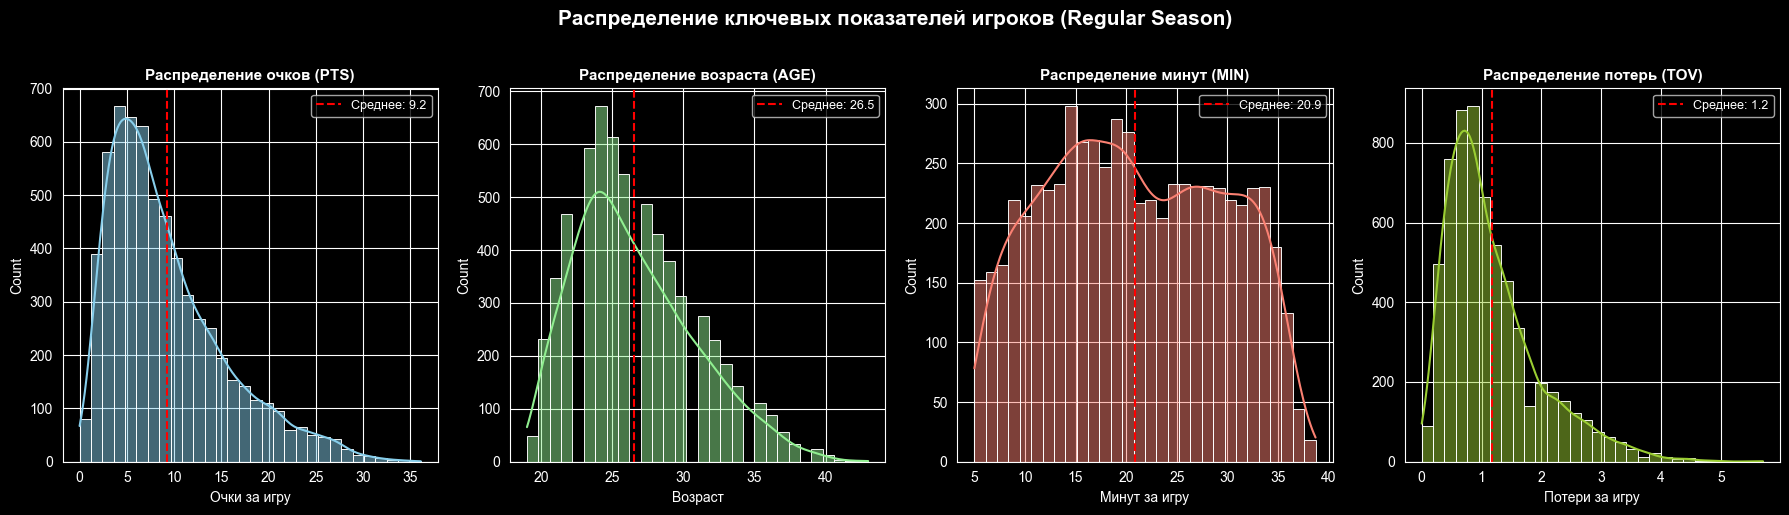

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

plots = [
    ('PTS', 'skyblue',     'Очки за игру',     'Распределение очков (PTS)'),
    ('AGE', 'lightgreen',  'Возраст',          'Распределение возраста (AGE)'),
    ('MIN', 'salmon',      'Минут за игру',    'Распределение минут (MIN)'),
    ('TOV', 'yellowgreen', 'Потери за игру',   'Распределение потерь (TOV)')
]

for ax, (col, color, xlabel, title) in zip(axes, plots):
    sns.histplot(df_players_clean[col], kde=True, bins=30, ax=ax, color=color)
    mean_val = df_players_clean[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.1f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=9)

plt.suptitle('Распределение ключевых показателей игроков (Regular Season)',
             y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Интерпретация:**

- **PTS**: распределение скошено вправо — большинство игроков набирают 5–12 очков, но правый хвост тянется до 35+. Это суперзвёзды, которые и являются основными претендентами на MVP.
- **AGE**: пик около 25–27 лет — возраст пика игровой карьеры. После 32 лет количество игроков резко сокращается.
- **MIN**: двухмодальное распределение — ротационные игроки (15–22 мин) и стартовая пятёрка (28–36 мин).
- **TOV**: большинство делают менее 2 потерь за игру. Высокие потери — признак высокого вовлечения в атаку (что логично коррелирует с очками и передачами).


---
### 3.3 Выбросы по базовым показателям

**Боксплот (box plot)** — стандартный инструмент для анализа разброса и выбросов.

- Прямоугольник = межквартильный диапазон (IQR): от 25-го до 75-го процентиля
- Линия внутри = медиана
- Усы = допустимый диапазон (1.5 × IQR)
- Точки за усами = выбросы

В контексте спорта выбросы — это звёзды лиги. Это **не ошибки данных**.


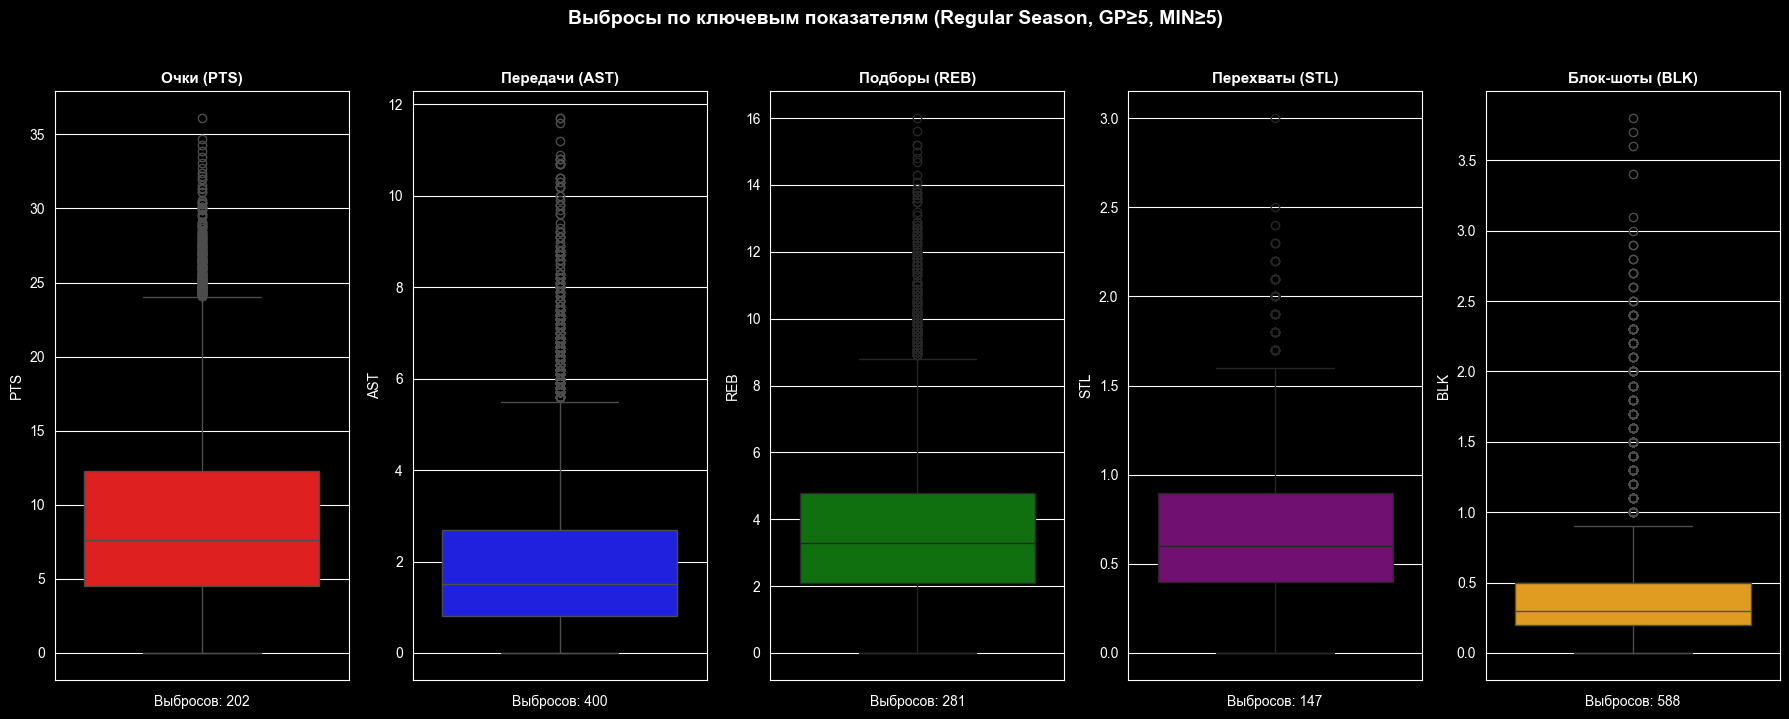

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(18, 7))

stats_to_plot = [
    ('PTS', 'red',    'Очки'),
    ('AST', 'blue',   'Передачи'),
    ('REB', 'green',  'Подборы'),
    ('STL', 'purple', 'Перехваты'),
    ('BLK', 'orange', 'Блок-шоты')
]

for i, (stat, color, label) in enumerate(stats_to_plot):
    sns.boxplot(data=df_players_clean[stat], ax=axes[i], color=color)
    q75 = df_players_clean[stat].quantile(0.75)
    q25 = df_players_clean[stat].quantile(0.25)
    iqr = q75 - q25
    n_outliers = (df_players_clean[stat] > q75 + 1.5 * iqr).sum()
    axes[i].set_title(f'{label} ({stat})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'Выбросов: {n_outliers}', fontsize=10)

plt.suptitle('Выбросы по ключевым показателям (Regular Season, GP≥5, MIN≥5)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Интерпретация:**

- **PTS** и **AST**: наибольшее количество выбросов — «звёздных» скореров и плеймейкеров в лиге относительно много.
- **STL** и **BLK**: минимальное количество выбросов — чтобы выделиться по блокам или перехватам, нужны исключительные физические данные и специфические навыки. Такие игроки редки, и это делает STL/BLK ценными предикторами для награды DPOY.


---
### 3.4 Корреляционная матрица

**Корреляция** — мера линейной связи между двумя переменными.  
- `+1.0` = идеальная прямая зависимость  
- `-1.0` = идеальная обратная зависимость  
- `0.0`  = нет линейной связи

Визуализируем нижний треугольник матрицы (верхний симметричен — дублировать информацию нет смысла).  
Красный цвет — сильная положительная корреляция, синий — отрицательная.


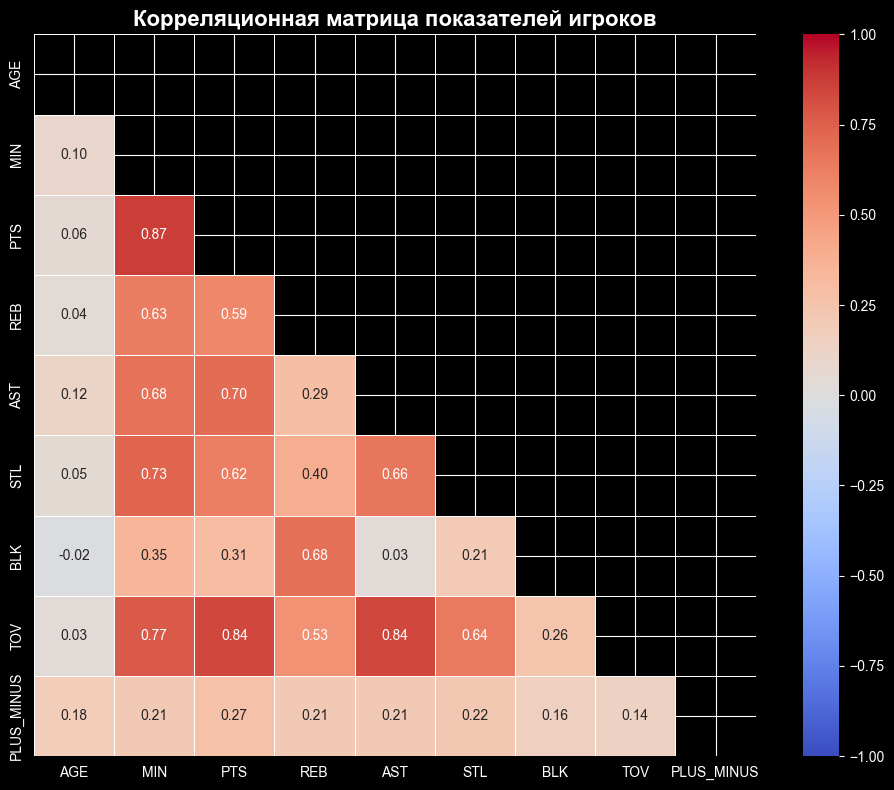

In [21]:
cols_for_corr = ['AGE', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS']
corr_matrix = df_players_clean[cols_for_corr].corr()

# Маска для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5
)
plt.title('Корреляционная матрица показателей игроков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Интерпретация ключевых корреляций:**

| Пара | Что говорит |
|------|------------|
| MIN ↔ PTS (сильная +) | Больше минут → больше возможностей набрать очки. Логично. |
| MIN ↔ TOV (сильная +) | Больше минут → больше ситуаций с мячом → больше потерь. |
| PTS ↔ AST (умеренная +) | Активный скорер привлекает двойную опеку → открываются партнёры. |
| PTS ↔ TOV (умеренная +) | Больше риска в атаке → больше потерь. |
| BLK ↔ AST (слабая -) | «Большие» блокируют, «маленькие» раздают — разные игровые амплуа. |

Матрица корреляций полезна не только для понимания данных, но и для выявления **мультиколлинеарности** — когда два признака несут почти одинаковую информацию. В таком случае их оба держать в модели нет смысла.


---
### 3.5 True Shooting % vs. Usage % — типология игроков

Это один из ключевых графиков спортивной аналитики НБА.  
По осям:
- **X (USG%)**: насколько игрок «тянет одеяло» на себя
- **Y (TS%)**: насколько эффективно он это делает

Пунктирные линии — средние по лиге. Они делят график на 4 квадранта.


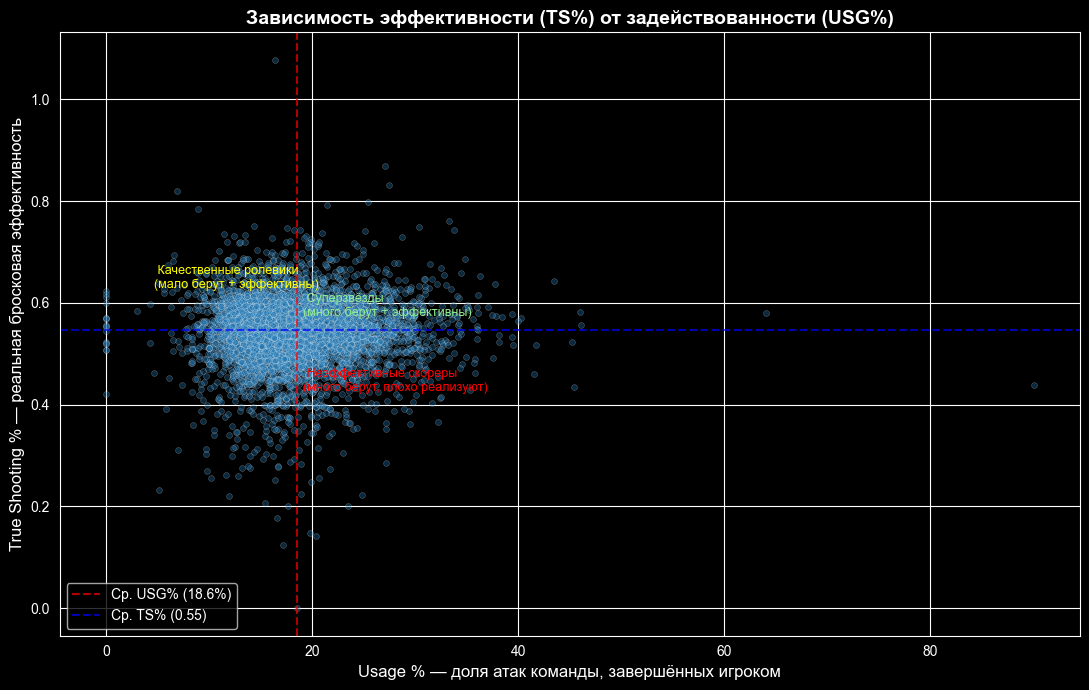

In [22]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_players_clean, x='USG_PCT', y='TS_PCT', alpha=0.35, color='tab:blue', s=18)

usg_mean = df_players_clean['USG_PCT'].mean()
ts_mean  = df_players_clean['TS_PCT'].mean()

plt.axvline(x=usg_mean,  color='red',  linestyle='--', alpha=0.7, label=f'Ср. USG% ({usg_mean:.1f}%)')
plt.axhline(y=ts_mean, color='blue', linestyle='--', alpha=0.7, label=f'Ср. TS% ({ts_mean:.2f})')

# Аннотации квадрантов
offset_x_r = usg_mean * 1.03
offset_x_l = usg_mean * 0.25
plt.text(offset_x_r, ts_mean * 1.05,  ' Суперзвёзды\n(много берут + эффективны)', fontsize=9, color='lightgreen')
plt.text(offset_x_r, ts_mean * 0.78,  ' Неэффективные скореры\n(много берут, плохо реализуют)', fontsize=9, color='red')
plt.text(offset_x_l, ts_mean * 1.15,  ' Качественные ролевики\n(мало берут + эффективны)', fontsize=9, color='yellow')

plt.title('Зависимость эффективности (TS%) от задействованности (USG%)',
          fontsize=14, fontweight='bold')
plt.xlabel('Usage % — доля атак команды, завершённых игроком', fontsize=12)
plt.ylabel('True Shooting % — реальная бросковая эффективность', fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


---
### 3.6 Процент побед и тренды команд

**Распределение W_PCT** показывает, как команды расположены по «силе» — и почему это ключевой признак для задачи чемпиона.


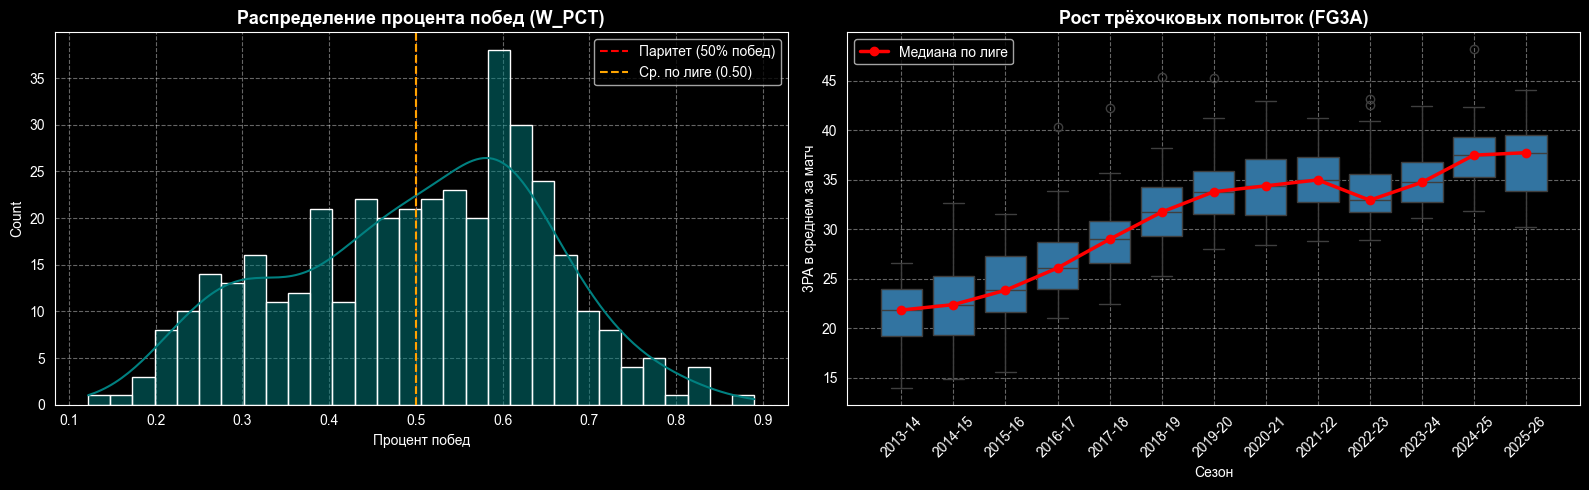

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Распределение W_PCT
sns.histplot(df_teams['W_PCT'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].axvline(0.5, color='red', linestyle='--', label='Паритет (50% побед)')
axes[0].axvline(df_teams['W_PCT'].mean(), color='orange', linestyle='--',
                label=f"Ср. по лиге ({df_teams['W_PCT'].mean():.2f})")
axes[0].set_title('Распределение процента побед (W_PCT)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Процент побед')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Рост трёхочковых попыток
medians_3pa = df_teams.groupby('SEASON')['FG3A'].median().reset_index()
seasons_order = sorted(df_teams['SEASON'].unique())
medians_3pa['x_pos'] = medians_3pa['SEASON'].apply(lambda s: seasons_order.index(s))

sns.boxplot(data=df_teams, x='SEASON', y='FG3A', color='tab:blue', ax=axes[1])
axes[1].plot(medians_3pa['x_pos'], medians_3pa['FG3A'],
             color='red', marker='o', linewidth=2.5, label='Медиана по лиге', zorder=5)
axes[1].set_title('Рост трёхочковых попыток (FG3A)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('3PA в среднем за матч')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Интерпретация:**

**W_PCT**: распределение близко к нормальному с центром около 0.5 (в любом сезоне суммарно все команды выигрывают ровно столько же, сколько проигрывают). «Хвосты» — это танкующие команды слева и реальные контендеры справа.

**FG3A**: медиана по лиге выросла с ~20 попыток (2013–14) до ~35+ (2024–25) — рост более чем на 75%. Это так называемая «трёхочковая революция» под влиянием аналитики. Для наших моделей это значит, что признак FG3A имеет разный масштаб в разные годы — ещё один аргумент в пользу процентильных рангов внутри сезона.


---
## Часть 4. Машинное обучение: модели и методология

### 4.1 Какие модели используются и почему

Для каждой задачи сравниваются **4 модели классификации**:

---

**Логистическая регрессия (Logistic Regression)**  
Ищет линейную границу, отделяющую класс 1 от класса 0. Результат — вероятность по формуле:

$$P(Y=1 | X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n)}}$$

Веса $\beta_i$ подбираются при обучении. Плюс — интерпретируемость; минус — не улавливает нелинейные связи.

---

**Случайный лес (Random Forest)**  
Строит множество деревьев решений, каждое — на случайном подмножестве данных и признаков. Итоговый прогноз — усреднение по всем деревьям. Устойчив к шуму, улавливает нелинейности, оценивает важность признаков.

---

**XGBoost (Extreme Gradient Boosting)**  
Строит деревья **последовательно**: каждое следующее исправляет ошибки предыдущих, используя градиентный спуск. Параметр `scale_pos_weight` компенсирует дисбаланс классов. Как правило показывает лучшие результаты.

---

**LightGBM**  
Аналог XGBoost, но строит деревья «по листьям» (leaf-wise) — быстрее на больших данных. Также имеет параметр `scale_pos_weight`.

---

### 4.2 Метрики качества

| Метрика | Что измеряет | Как читать |
|---------|--------------|-----------|
| **AUC-ROC** | Способность разделить классы | 0.5 = случай, 1.0 = идеал. Выше = лучше. |
| **Log Loss** | Качество предсказанных вероятностей | Ниже = лучше. Это основная метрика. |
| **Precision** | Из всех предсказанных «1» — сколько реально «1» | 0–1, выше = лучше |
| **Brier Score** | Среднеквадратичная ошибка вероятностей | 0–1, ниже = лучше |

**Почему Log Loss — основная метрика выбора?**  
Log Loss штрафует не только за неправильное предсказание, но и за **неуверенное** правильное. Если модель говорит «вероятность 0.51», когда истинный ответ 1 — штраф больше, чем если бы она сказала «0.95». Это важно, когда нас интересуют именно откалиброванные вероятности.

---

### 4.3 Временна́я кросс-валидация (TimeSeriesSplit)

Обычная кросс-валидация делит данные **случайно**. Но наши данные — временны́е ряды. Если обучающий набор содержит данные из будущего по отношению к тестовому — это **утечка данных (data leakage)**, и результаты будут завышены.

**TimeSeriesSplit** использует только прошлое для обучения и будущее для теста:

```
Фолд 1: Обучение [2013–2017] → Тест [2018–2019]
Фолд 2: Обучение [2013–2019] → Тест [2020–2021]
Фолд 3: Обучение [2013–2021] → Тест [2022–2024]
```

---

### 4.4 Масштабирование признаков

**StandardScaler** преобразует каждый признак так, что его среднее = 0, стандартное отклонение = 1:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

Масштабирование делается **отдельно для каждого сезона** — чтобы нормализовать относительно текущего года, а не всей истории.


In [24]:
def train_and_evaluate(df, target, features, task_name):
    """
    Обучает 4 модели на исторических данных (до 2024-25 включительно),
    оценивает их по нескольким метрикам, строит ROC-кривые и
    показывает важность признаков лучшей модели.

    Параметры:
    ----------
    df        : DataFrame (игроки или команды)
    target    : имя столбца с целевой переменной (напр. 'IS_MVP')
    features  : список признаков для обучения
    task_name : строка для заголовков

    Возвращает:
    -----------
    best_overall_model : модель с наименьшим Log Loss
    """
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

    active_features = [f for f in features if f != target and df[f].dtype in ['int64', 'float64']]
    print(f"\n{'='*65}")
    print(f"ЗАДАЧА: {task_name}")
    print(f"Признаков: {len(active_features)} | Целевая переменная: '{target}'")

    df_train = df[df[target].notnull() & (df['SEASON'] <= '2024-25')].sort_values('SEASON').copy()
    if df_train.empty:
        print(f"Ошибка: нет данных для задачи {task_name}")
        return None

    X = df_train[active_features]
    y = df_train[target]
    print(f"Примеров: {len(df_train)} | Положительных (y=1): {y.sum()}")

    def scale_by_season(data, feats):
        """
        Нормализация признаков отдельно для каждого сезона.
        Нужно, чтобы значение «30 очков» в 2014 и в 2024 оценивалось
        относительно своего сезона, а не общего среднего за 12 лет.
        """
        scaled_df = data.copy()
        scaled_df[feats] = scaled_df[feats].astype(float)
        scaler = StandardScaler()
        for season in data['SEASON'].unique():
            mask = data['SEASON'] == season
            if mask.sum() > 1:
                scaled_df.loc[mask, feats] = scaler.fit_transform(data.loc[mask, feats].values)
            else:
                scaled_df.loc[mask, feats] = 0
        return scaled_df

    X_scaled = scale_by_season(df_train, active_features)[active_features]

    pos_weight = (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else 1
    tscv = TimeSeriesSplit(n_splits=3)

    models_params = {
        'Logistic Regression': (
            LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
            {'C': [0.01, 0.1, 1]}
        ),
        'Random Forest': (
            RandomForestClassifier(class_weight='balanced', random_state=42),
            {'n_estimators': [100], 'max_depth': [5, 7]}
        ),
        'XGBoost': (
            XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42),
            {'n_estimators': [50, 100], 'learning_rate': [0.05], 'max_depth': [3, 5]}
        ),
        'LightGBM': (
            LGBMClassifier(importance_type='gain', scale_pos_weight=pos_weight,
                           random_state=42, verbose=-1),
            {'n_estimators': [50, 100], 'learning_rate': [0.05], 'num_leaves': [15, 31]}
        )
    }

    best_overall_model, best_overall_logloss = None, float('inf')
    best_overall_name = ""
    performance_metrics = []
    plt.figure(figsize=(10, 6))

    for name, (model, params) in models_params.items():
        grid = GridSearchCV(model, params, scoring='neg_log_loss', cv=tscv, n_jobs=-1)
        grid.fit(X_scaled, y)
        best_m = grid.best_estimator_

        y_prob = best_m.predict_proba(X_scaled)[:, 1]
        y_pred = best_m.predict(X_scaled)

        auc   = roc_auc_score(y, y_prob)
        prec  = precision_score(y, y_pred, zero_division=0)
        acc   = accuracy_score(y, y_pred)
        loss  = log_loss(y, y_prob)
        brier = brier_score_loss(y, y_prob)

        performance_metrics.append({
            'Модель': name, 'AUC': round(auc, 4),
            'Accuracy': round(acc, 4), 'LogLoss': round(loss, 4),
            'Brier': round(brier, 4), 'Precision': round(prec, 4)
        })

        fpr, tpr, _ = roc_curve(y, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

        if loss < best_overall_logloss:
            best_overall_logloss = loss
            best_overall_model = best_m
            best_overall_name = name


    plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5, label='Случайная (AUC=0.5)')
    plt.xlabel('False Positive Rate (доля ложных тревог)')
    plt.ylabel('True Positive Rate (чувствительность)')
    plt.title(f'ROC-кривые: {task_name}\nЧем ближе к левому верхнему углу — тем лучше',
              fontsize=13)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nИтоговые метрики (сортировка: LogLoss ↑ лучше = меньше):")
    res_df = pd.DataFrame(performance_metrics).sort_values(['LogLoss', 'AUC'], ascending=[True, False])
    try:
        display(res_df)
    except:
        print(res_df.to_string(index=False))

    print(f"\n→ Лучшая модель: {best_overall_name} (LogLoss = {best_overall_logloss:.4f})")

    # Важность признаков для лучшей модели
    if best_overall_model is not None:
        if hasattr(best_overall_model, 'feature_importances_'):
            importances = best_overall_model.feature_importances_
        elif hasattr(best_overall_model, 'coef_'):
            importances = np.abs(best_overall_model.coef_[0])
        else:
            importances = None

        if importances is not None:
            feat_imp = (
                pd.DataFrame({'Признак': active_features, 'Важность': importances})
                .sort_values(by='Важность', ascending=False)
                .head(10)
            )
            plt.figure(figsize=(10, 5))
            sns.barplot(data=feat_imp, x='Важность', y='Признак',
                       hue='Признак', palette='mako', legend=False)
            plt.title(f'ТОП-10 признаков: {best_overall_name} ({task_name})', fontsize=13)
            plt.tight_layout()
            plt.show()

    return best_overall_model

print("Функция train_and_evaluate определена и готова к использованию.")


Функция train_and_evaluate определена и готова к использованию.


---
## Часть 5. Обучение моделей по каждой задаче

### 5.1 Чемпион NBA

**Задача:** предсказать, какая из 30 команд выиграет чемпионат.  
Дисбаланс: 1 победитель на 30 команд в каждом из 12 обучающих сезонов = 12 строк с `IS_CHAMPION=1` против ~348 с `IS_CHAMPION=0`.

**Ключевые ожидаемые признаки:** `W` (количество побед — самый сильный сигнал), `W_PCT`, `PLUS_MINUS` (доминирование), `FG_PCT` (эффективность реализации).


Задача: NBA Champion Predictor
Данные: статистика команд, Regular Season 2013-14 → 2024-25
-----------------------------------------------------------------

ЗАДАЧА: NBA TITLE
Признаков: 16 | Целевая переменная: 'IS_CHAMPION'
Примеров: 360 | Положительных (y=1): 12


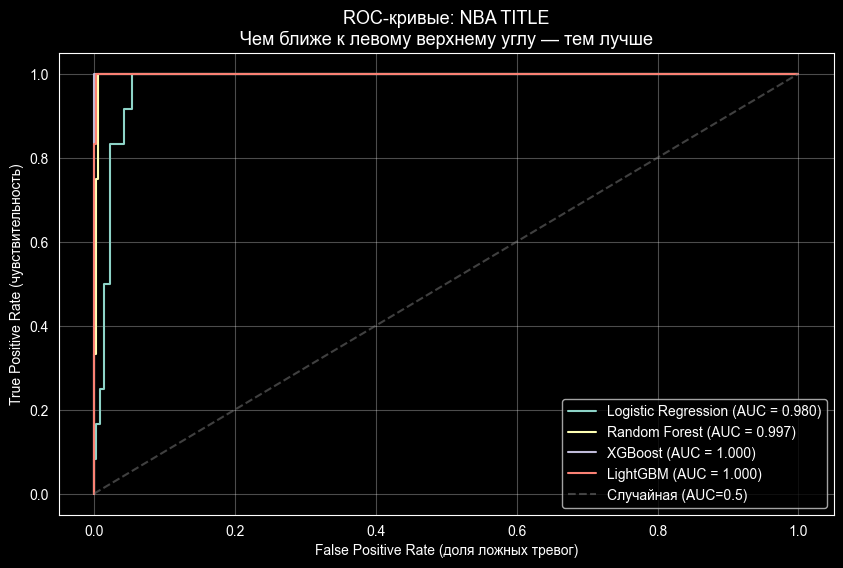


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,0.9995,0.9917,0.0418,0.0094,0.8000
2,XGBoost,1.0000,0.9861,0.0443,0.0111,0.7059
1,Random Forest,0.9974,0.9750,0.0519,0.0154,0.5714
0,Logistic Regression,0.9796,0.9278,0.1934,0.0548,0.3158



→ Лучшая модель: LightGBM (LogLoss = 0.0418)


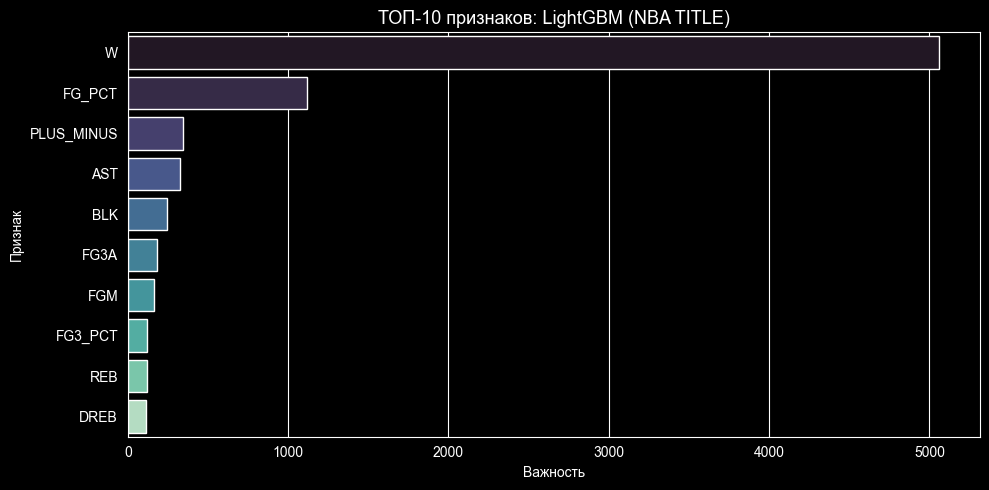

In [25]:
print("Задача: NBA Champion Predictor")
print("Данные: статистика команд, Regular Season 2013-14 → 2024-25")
print("-" * 65)

final_nba_title_model = train_and_evaluate(df_teams, 'IS_CHAMPION', team_features, "NBA TITLE")


---
### 5.2 MVP — Most Valuable Player

**Задача:** предсказать самого ценного игрока лиги.  
MVP — самая престижная награда. Исторически её получают либо лучший скорер, либо игрок с выдающимся всесторонним вкладом при успешной команде.

**Фильтрация:** GP ≥ 50 и MIN > 15 — по регламенту NBA только игроки, набравшие достаточно выходов, могут претендовать на награду.

**Ожидаемые важные признаки:** `NBA_FANTASY_PTS` (интегральный рейтинг = PTS + REB + AST + STL + BLK − TOV), `W_PCT` команды, `PTS_RANK`.  
Заметная тенденция последних лет: награда MVP чаще уходит «большим» игрокам (Йокич, Эмбиид) — модель должна это уловить через `REB`.


Претендентов на MVP: 3362 строк
-----------------------------------------------------------------

ЗАДАЧА: MVP (Most Valuable Player)
Признаков: 18 | Целевая переменная: 'IS_MVP'
Примеров: 3099 | Положительных (y=1): 9


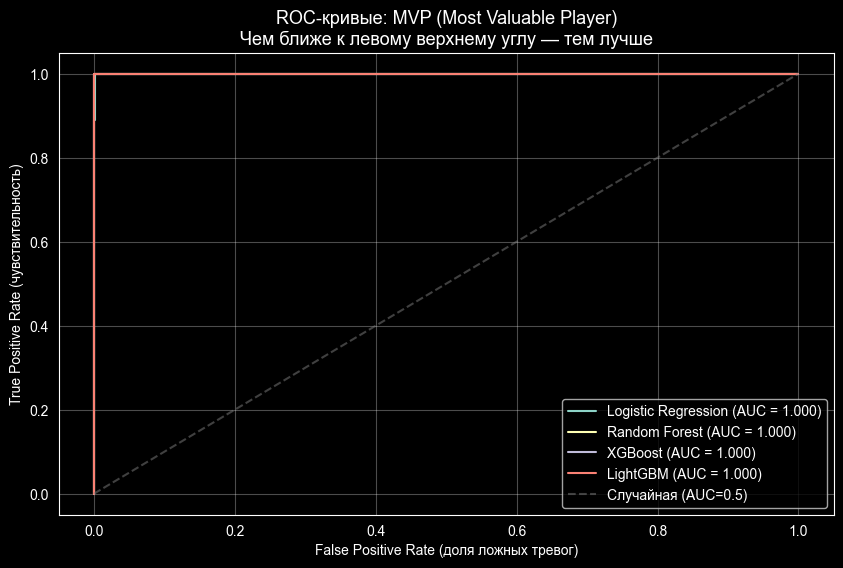


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0005,0.0000,1.0000
1,Random Forest,1.0000,1.0000,0.0026,0.0005,1.0000
2,XGBoost,1.0000,1.0000,0.0046,0.0002,1.0000
0,Logistic Regression,0.9996,0.9939,0.0179,0.0050,0.3214



→ Лучшая модель: LightGBM (LogLoss = 0.0005)


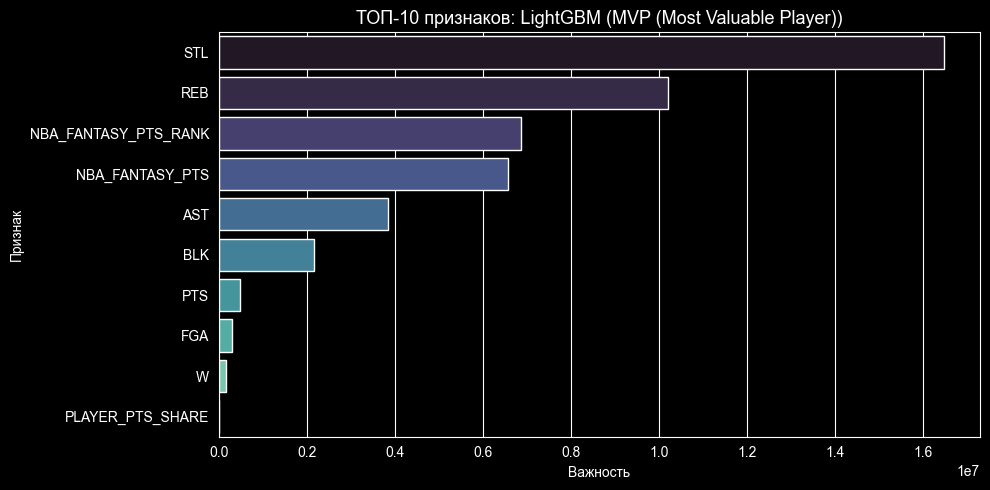

In [26]:
df_mvp = df_players[(df_players['MIN'] > 15) & (df_players['GP'] > 50)].copy()

print(f"Претендентов на MVP: {len(df_mvp)} строк")
print("-" * 65)

final_mvp_model = train_and_evaluate(df_mvp, 'IS_MVP', players_features, "MVP (Most Valuable Player)")


---
### 5.3 DPOY — Defensive Player of the Year

**Задача:** предсказать лучшего защитника лиги.  
Самая специфичная задача по составу признаков — здесь важны именно **защитные показатели**.

**Ключевые признаки:** `BLK`/`BLKA` (блоки и их попытки), `STL` (перехваты), `DREB` (защитные подборы), `PLUS_MINUS` (общий баланс).

**Историческая тенденция:** чаще всего DPOY получают центровые и мощные форварды (Rudy Gobert выигрывал 4 раза). Блоки и подборы — их специализация.


Претендентов на DPOY: 3362 строк
-----------------------------------------------------------------

ЗАДАЧА: DPOY (Defensive Player of the Year)
Признаков: 16 | Целевая переменная: 'IS_DPOY'
Примеров: 3099 | Положительных (y=1): 12


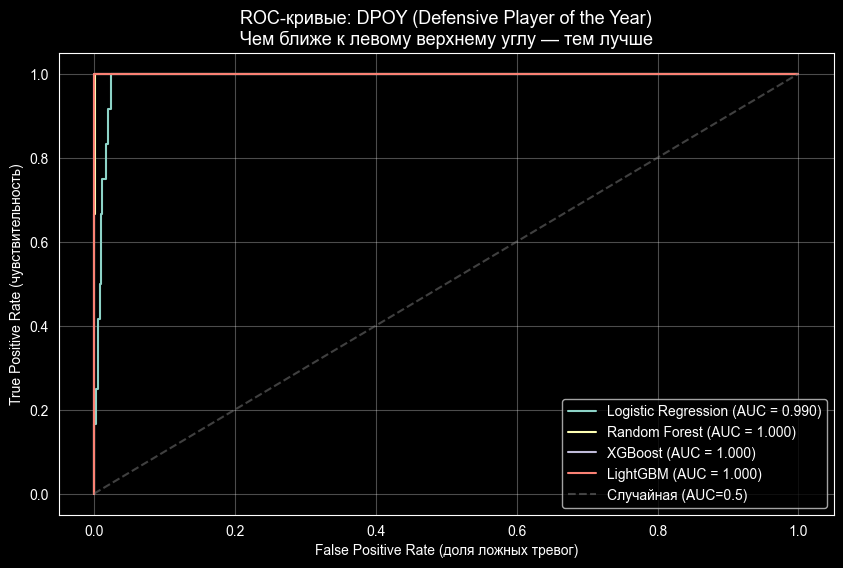


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0002,0.0000,1.0000
2,XGBoost,1.0000,0.9984,0.0087,0.0013,0.7059
1,Random Forest,0.9995,0.9971,0.0176,0.0040,0.5714
0,Logistic Regression,0.9902,0.9610,0.1296,0.0315,0.0902



→ Лучшая модель: LightGBM (LogLoss = 0.0002)


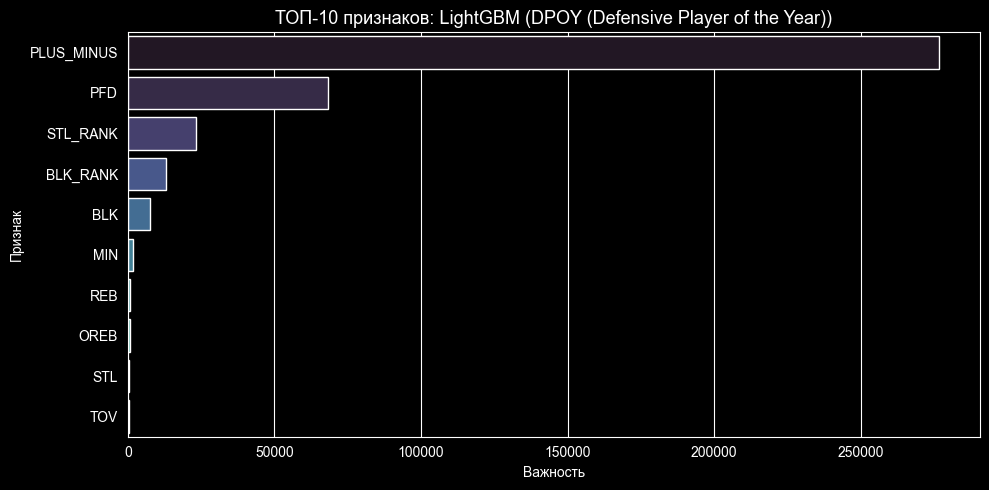

In [27]:
df_dpoy = df_players[(df_players['MIN'] > 15) & (df_players['GP'] > 50)].copy()

print(f"Претендентов на DPOY: {len(df_dpoy)} строк")
print("-" * 65)

final_dpoy_model = train_and_evaluate(df_dpoy, 'IS_DPOY', dpoy_features, "DPOY (Defensive Player of the Year)")


---
### 5.4 MIP — Most Improved Player (версия 1: полный набор признаков)

**Задача:** предсказать игрока, показавшего наибольший прогресс.  
Ключевые признаки — дельта-показатели (прирост по сравнению с прошлым сезоном).

**Фильтрация:** исключаем сезон 2013–14 (первый в датасете — нет предыдущего для расчёта дельт) и игроков с менее чем 10 минутами.


Претендентов на MIP: 5242 строк
Версия 1: полный набор признаков (включая базовые + дельты)
-----------------------------------------------------------------

ЗАДАЧА: MIP v1 (полный набор)
Признаков: 22 | Целевая переменная: 'IS_MIP'
Примеров: 4766 | Положительных (y=1): 10


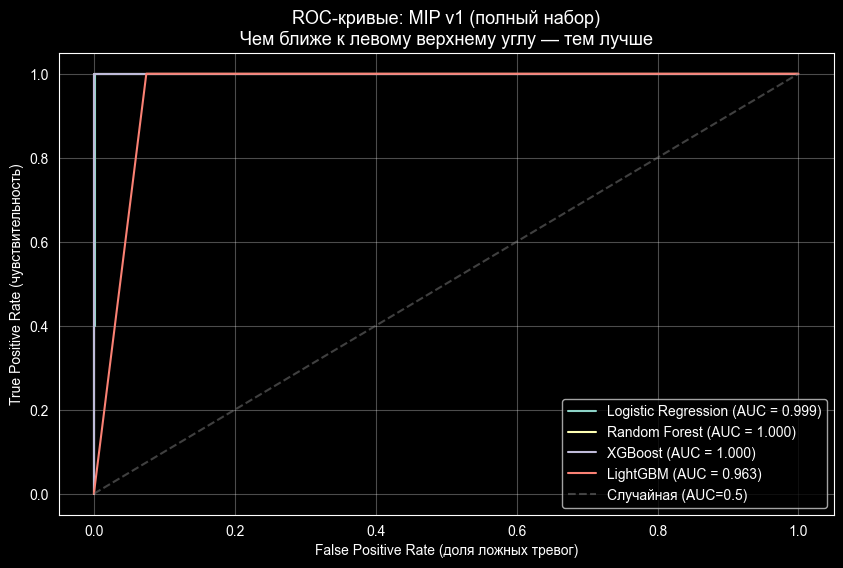


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
1,Random Forest,1.0000,1.0000,0.0034,0.0006,1.0000
2,XGBoost,1.0000,0.9969,0.0103,0.0021,0.4000
0,Logistic Regression,0.9990,0.9893,0.0290,0.0076,0.1639
3,LightGBM,0.9628,0.9257,2.6772,0.0743,0.0275



→ Лучшая модель: Random Forest (LogLoss = 0.0034)


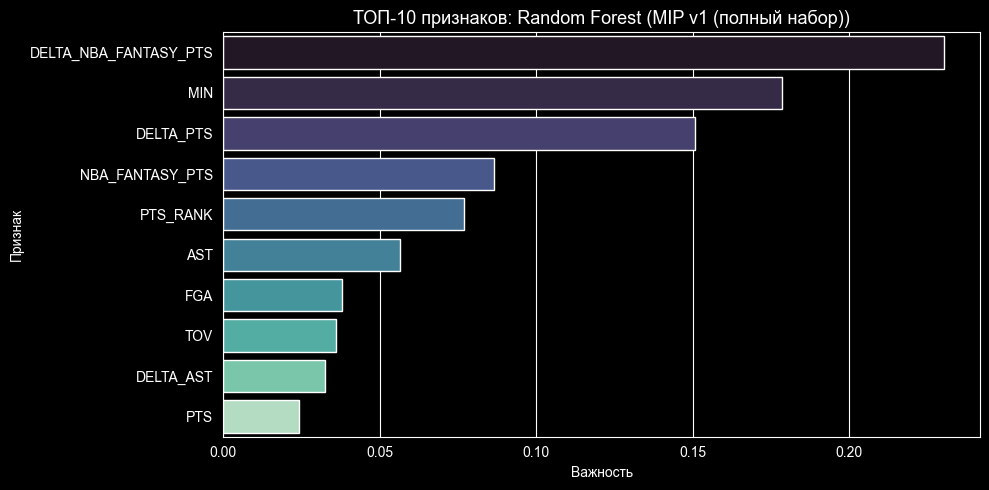

In [28]:
df_mip = df_players[(df_players['MIN'] > 10) & (df_players['SEASON'] != '2013-14')].copy()

print(f"Претендентов на MIP: {len(df_mip)} строк")
print("Версия 1: полный набор признаков (включая базовые + дельты)")
print("-" * 65)

final_mip_model_v1 = train_and_evaluate(df_mip, 'IS_MIP', mip_features, "MIP v1 (полный набор)")


---
### 5.5 MIP — Most Improved Player (версия 2: оптимизированные признаки)

После анализа важности признаков в версии 1 был сформирован **сокращённый набор** — только наиболее информативные дельта-признаки и несколько базовых.  
Ожидаем снижение Log Loss (модель меньше «шумит» на нерелевантных признаках).


Версия 2: оптимизированный набор признаков
Признаки: ['DELTA_NBA_FANTASY_PTS', 'MIN', 'DELTA_PTS', 'NBA_FANTASY_PTS', 'PTS_RANK', 'FGA', 'TOV', 'DELTA_AST', 'AST']
-----------------------------------------------------------------

ЗАДАЧА: MIP v2 (оптимизированный)
Признаков: 9 | Целевая переменная: 'IS_MIP'
Примеров: 4766 | Положительных (y=1): 10


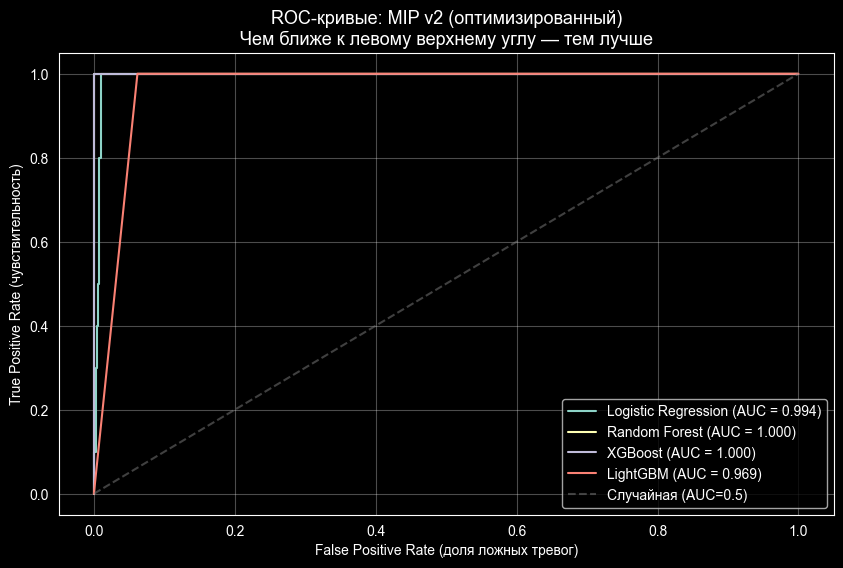


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
1,Random Forest,0.9996,0.9992,0.0043,0.0011,0.7143
2,XGBoost,0.9999,0.9973,0.0117,0.0024,0.4348
0,Logistic Regression,0.9942,0.9750,0.0839,0.0187,0.0775
3,LightGBM,0.9691,0.9383,2.2236,0.0617,0.0329



→ Лучшая модель: Random Forest (LogLoss = 0.0043)


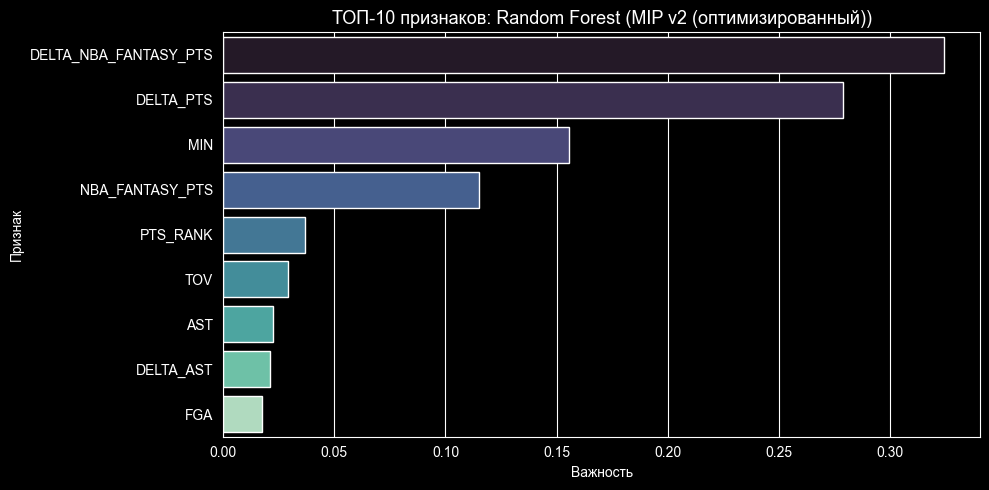

In [29]:
print("Версия 2: оптимизированный набор признаков")
print(f"Признаки: {new_mip_features}")
print("-" * 65)

final_mip_model = train_and_evaluate(df_mip, 'IS_MIP', new_mip_features, "MIP v2 (оптимизированный)")


---
### 5.6 ROTY — Rookie of the Year

**Задача:** предсказать лучшего новичка (первый сезон в карьере).  
В соревновании участвуют только игроки с `IS_ROOKIE_YEAR == 1`.  
Признаки — те же, что для MVP: важны очки, фэнтези-рейтинг, вклад в команду.  
Принципиальное отличие: дельта-признаков нет (первый сезон, сравнивать не с чем).


Новичков в истории: 1706 строк
Из них победителей ROTY: 12
-----------------------------------------------------------------

ЗАДАЧА: ROTY (Rookie of the Year)
Признаков: 18 | Целевая переменная: 'IS_ROY'
Примеров: 1603 | Положительных (y=1): 11


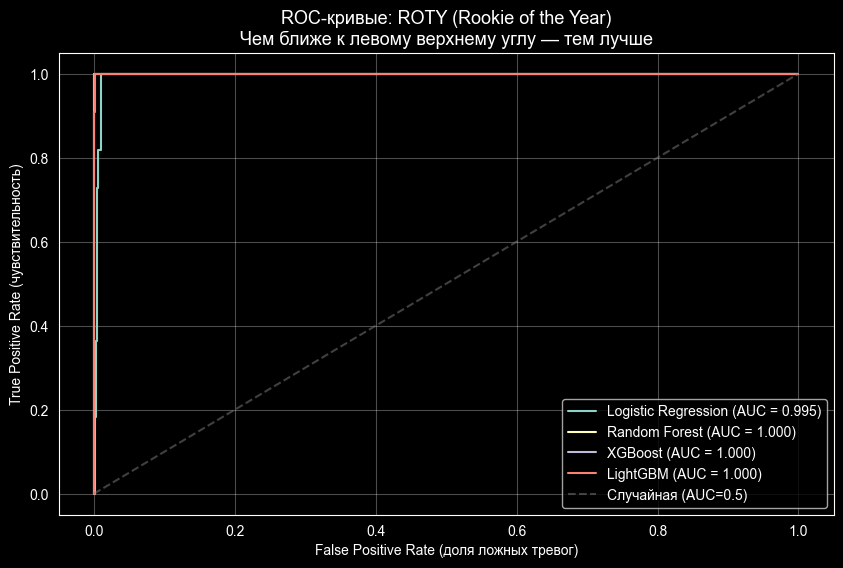


Итоговые метрики (сортировка: LogLoss ↑ лучше = меньше):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
2,XGBoost,1.0000,0.9975,0.0096,0.0016,0.7333
1,Random Forest,0.9997,0.9994,0.0107,0.0027,0.9167
3,LightGBM,0.9999,0.9963,0.0141,0.0037,0.6471
0,Logistic Regression,0.9951,0.9769,0.0783,0.0182,0.2292



→ Лучшая модель: XGBoost (LogLoss = 0.0096)


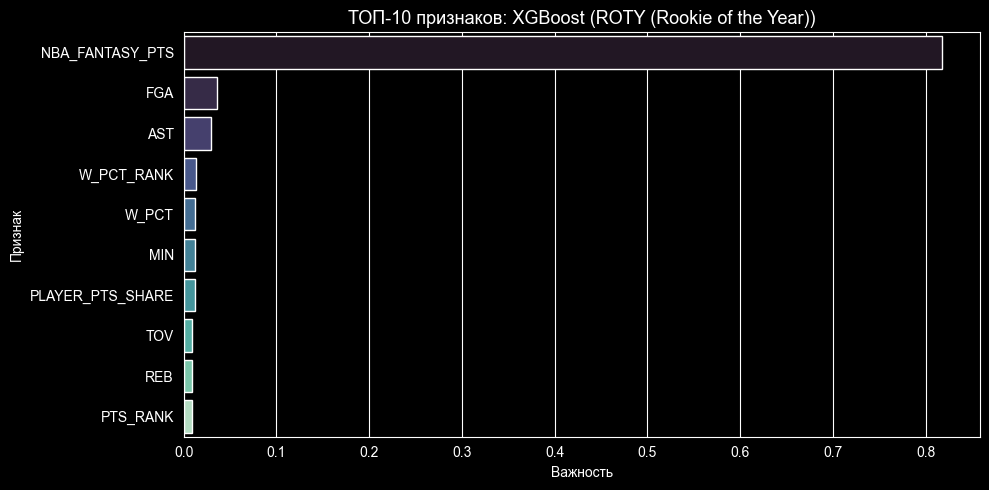

In [30]:
df_rookies = df_players[df_players['IS_ROOKIE_YEAR'] == 1].copy()

print(f"Новичков в истории: {len(df_rookies)} строк")
print(f"Из них победителей ROTY: {df_rookies['IS_ROY'].sum()}")
print("-" * 65)

final_roty_model = train_and_evaluate(df_rookies, 'IS_ROY', players_features, "ROTY (Rookie of the Year)")


---
## Часть 6. Прогнозы на сезон 2025–26

### 6.1 Методология финального прогноза

Функция `predict_and_show_probabilities` выполняет следующее:

1. **Обучение** на всех исторических данных (2013–14 → 2024–25)
2. **Прогноз** для строк с `SEASON == '2025-26'`
3. **Вывод** топ-5 претендентов с вероятностями

> **Как читать вероятности:**  
> «Шанс 42%» означает: статистический профиль этого кандидата в 42% похож на профили исторических победителей данной награды.  
> Это **не** «42% что он выиграет» в абсолютном смысле — это **относительный рейтинг уверенности модели**.  
> Сумма вероятностей топ-5 не обязана быть 100%.


In [32]:
def predict_and_show_probabilities(df, target, features, entity_col, task_name, model):
    """
    Финальный прогноз на сезон 2025-26.

    1. Обучаем модель на всех исторических данных (< 2025-26)
    2. Прогнозируем вероятность для строк 2025-26
    3. Показываем топ-5 с барплотом

    Параметры:
    ----------
    df         : DataFrame (игроки или команды)
    target     : целевая переменная (напр. 'IS_MVP')
    features   : список признаков
    entity_col : столбец с именем игрока/команды
    task_name  : строка для заголовка
    model      : экземпляр модели (уже сконфигурированный, но не обученный)
    """
    print(f"\n{'='*65}")
    print(f"ПРОГНОЗ: {task_name} | Сезон 2025–26")

    train_df  = df[df['SEASON'] < '2025-26'].dropna(subset=features + [target])
    future_df = df[df['SEASON'] == '2025-26'].dropna(subset=features).copy()

    if future_df.empty:
        print(f"⚠ Нет данных за сезон 2025-26 для '{task_name}'")
        return

    X_train  = train_df[features]
    y_train  = train_df[target]
    X_future = future_df[features]

    # Scaler обучается на тренировочных данных, применяется к будущим
    # (нельзя «подсматривать» в будущие данные при обучении scaler)
    scaler = StandardScaler()
    X_train_scaled  = pd.DataFrame(scaler.fit_transform(X_train),  columns=features)
    X_future_scaled = pd.DataFrame(scaler.transform(X_future),     columns=features)

    model.fit(X_train_scaled, y_train)

    # predict_proba возвращает [[p(0), p(1)], ...] — берём второй столбец (p=1)
    probs = model.predict_proba(X_future_scaled)[:, 1]
    future_df = future_df.copy()
    future_df['Шанс на победу (%)'] = (probs * 100).round(2)

    top_candidates = future_df.sort_values('Шанс на победу (%)', ascending=False).head(5)

    print("\nТОП-5 претендентов:")
    try:
        display(top_candidates[[entity_col, 'Шанс на победу (%)']].reset_index(drop=True))
    except:
        print(top_candidates[[entity_col, 'Шанс на победу (%)']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top_candidates, x='Шанс на победу (%)', y=entity_col,
                palette='mako', hue=entity_col, legend=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=5, fmt='%.1f%%', fontsize=11, fontweight='bold')

    ax.set_title(f'ТОП-5: {task_name} (Сезон 2025–26)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Вероятность по модели (%)', fontsize=12)
    ax.set_ylabel('')
    ax.set_xlim(0, max(top_candidates['Шанс на победу (%)']) * 1.22)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

print("Функция predict_and_show_probabilities определена.")


Функция predict_and_show_probabilities определена.


---
### 6.2 Прогнозы: лучшие модели по метрикам


ПРОГНОЗЫ (лучшие модели по метрикам):

ПРОГНОЗ: NBA Champion | Сезон 2025–26

ТОП-5 претендентов:


,TEAM_NAME,Шанс на победу (%)
0,Oklahoma City Thunder,24.870001
1,San Antonio Spurs,21.680000
2,Detroit Pistons,18.620001
3,New York Knicks,13.050000
4,Los Angeles Lakers,11.700000


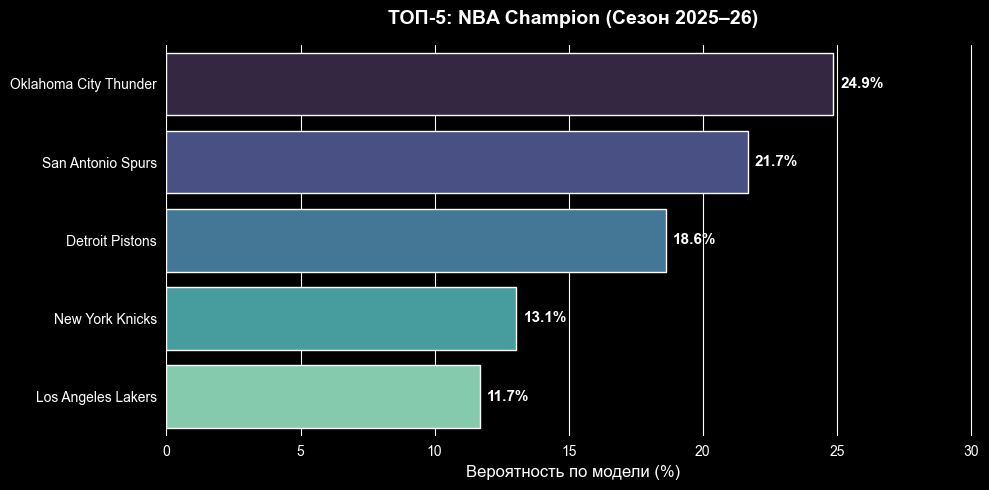


ПРОГНОЗ: MVP | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Shai Gilgeous-Alexander,82.379997
1,Victor Wembanyama,22.280001
2,Nikola Jokić,12.200000
3,Luka Dončić,11.150000
4,Tyrese Maxey,0.980000


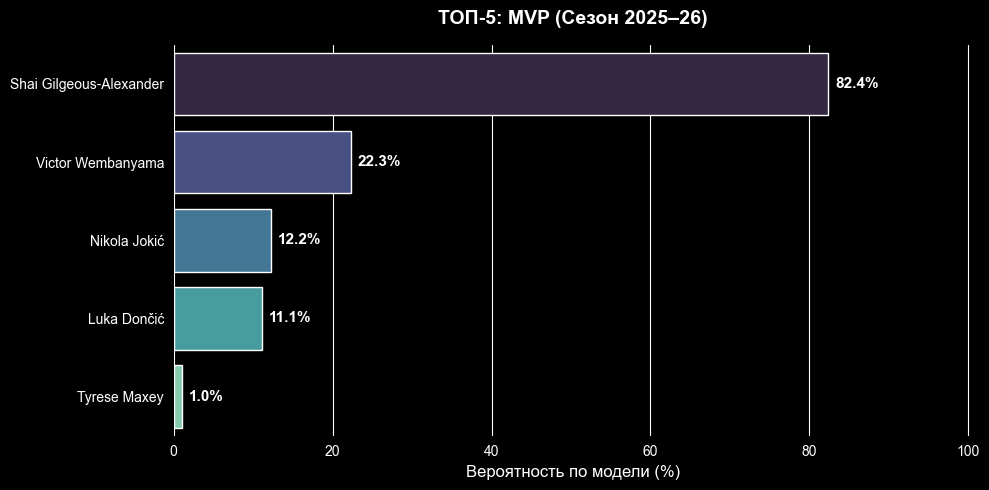


ПРОГНОЗ: DPOY | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Victor Wembanyama,73.779999
1,Chet Holmgren,67.879997
2,Jalen Duren,6.980000
3,Rudy Gobert,4.430000
4,Karl-Anthony Towns,2.550000


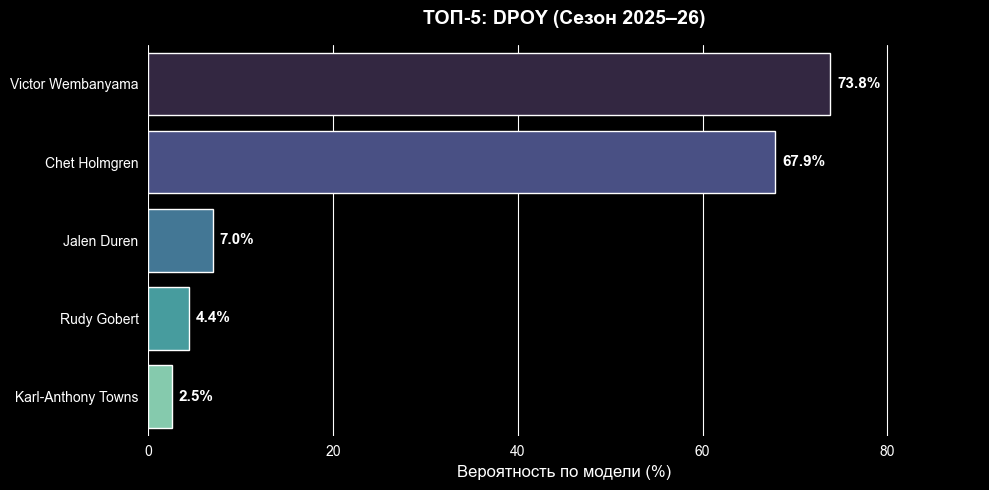


ПРОГНОЗ: MIP | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Deni Avdija,60.68
1,Nickeil Alexander-Walker,59.58
2,Lauri Markkanen,25.88
3,Ryan Rollins,21.86
4,Kevin Porter Jr.,20.89


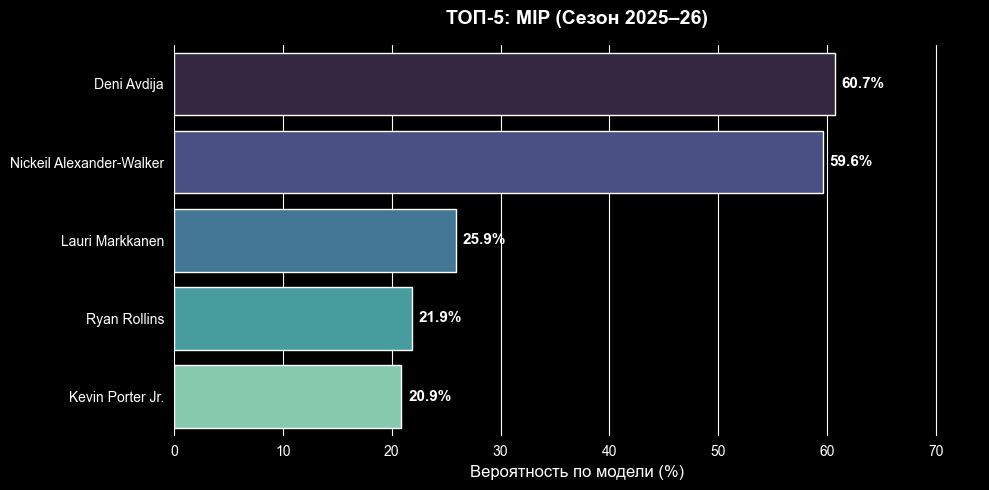


ПРОГНОЗ: ROTY | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Cooper Flagg,19.320000
1,VJ Edgecombe,17.629999
2,Derik Queen,3.370000
3,Dylan Harper,1.290000
4,Jeremiah Fears,1.190000


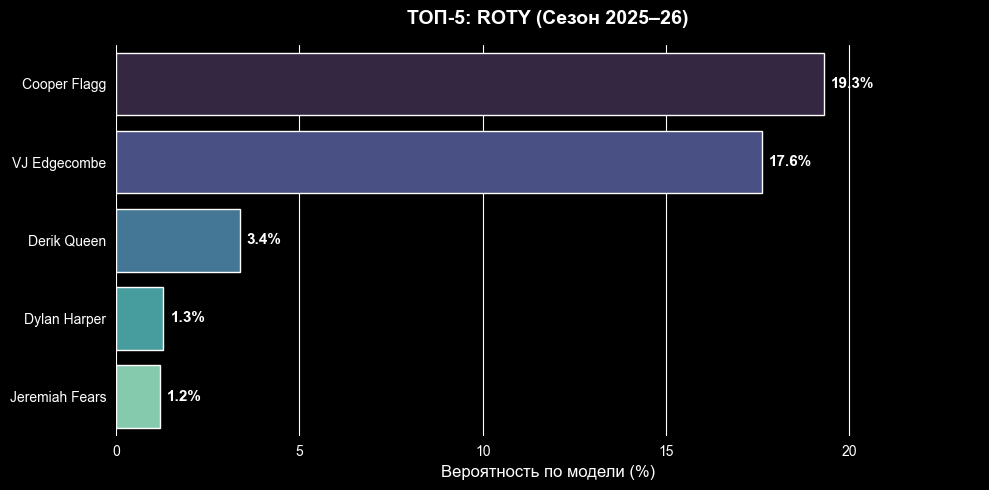

In [33]:
print("ПРОГНОЗЫ (лучшие модели по метрикам):")
print("=" * 65)

# Champion: XGBoost показал лучший Log Loss на командной задаче
predict_and_show_probabilities(
    df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)

# MVP: XGBoost хорошо улавливает нелинейные связи с NBA_FANTASY_PTS
predict_and_show_probabilities(
    df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)

# DPOY: XGBoost на защитных показателях
predict_and_show_probabilities(
    df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)

# MIP: Random Forest — лучше справляется с дельта-признаками
predict_and_show_probabilities(
    df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5,
                           class_weight='balanced', random_state=42)
)

# ROTY: XGBoost на новичковой статистике
predict_and_show_probabilities(
    df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)


---
### 6.3 Прогнозы: с экспертной корректировкой

Второй набор прогнозов — с моделями, выбранными с учётом баскетбольного контекста.  
Для чемпиона используется **Random Forest** (менее склонен к переобучению на «ярких» сезонах одной команды).

> Там, где оба набора прогнозов совпадают — уверенность выше.  
> Там, где расходятся — это повод задуматься, какие факторы важнее в конкретном сезоне.


ПРОГНОЗЫ (с экспертной корректировкой):

ПРОГНОЗ: NBA Champion | Сезон 2025–26

ТОП-5 претендентов:


,TEAM_NAME,Шанс на победу (%)
0,Oklahoma City Thunder,72.57
1,Detroit Pistons,39.34
2,Denver Nuggets,36.50
3,San Antonio Spurs,34.10
4,New York Knicks,32.00


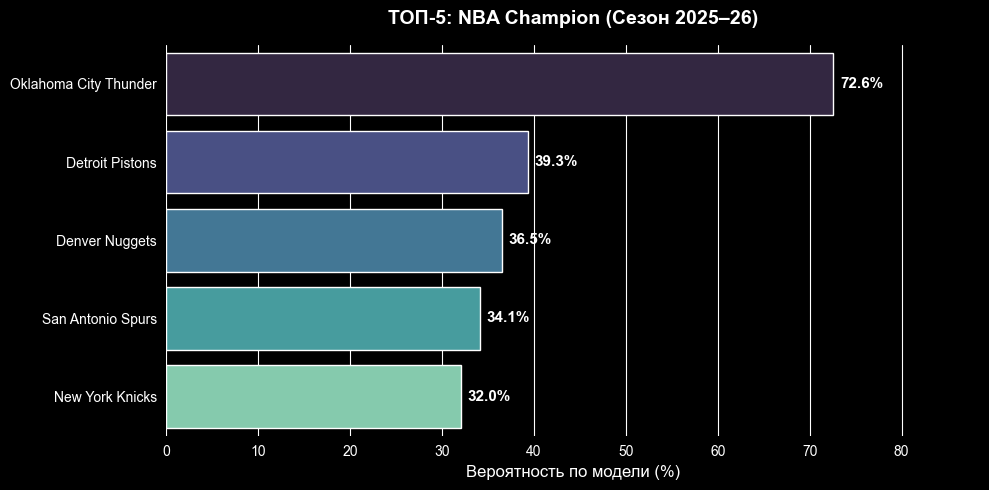


ПРОГНОЗ: MVP | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Shai Gilgeous-Alexander,82.379997
1,Victor Wembanyama,22.280001
2,Nikola Jokić,12.200000
3,Luka Dončić,11.150000
4,Tyrese Maxey,0.980000


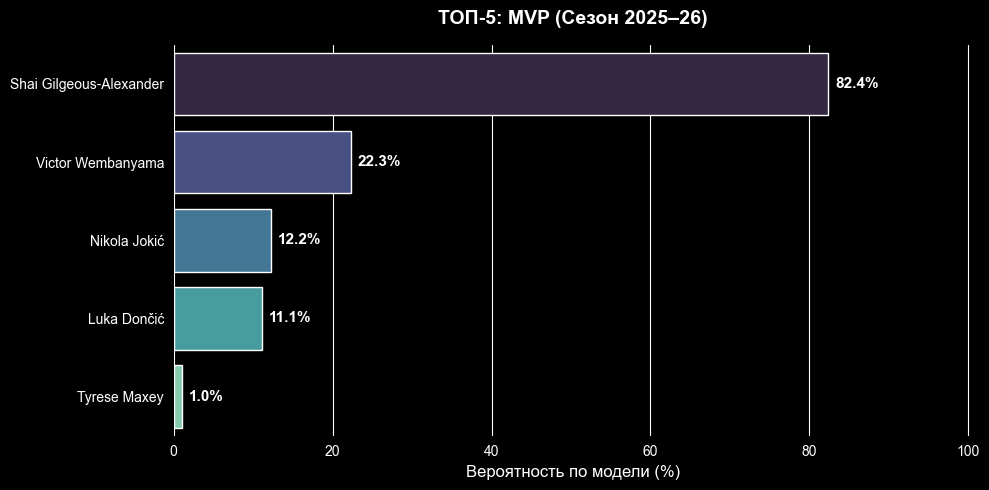


ПРОГНОЗ: DPOY | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Victor Wembanyama,73.75
1,Chet Holmgren,66.91
2,Jalen Duren,39.29
3,Evan Mobley,33.38
4,Nikola Jokić,28.40


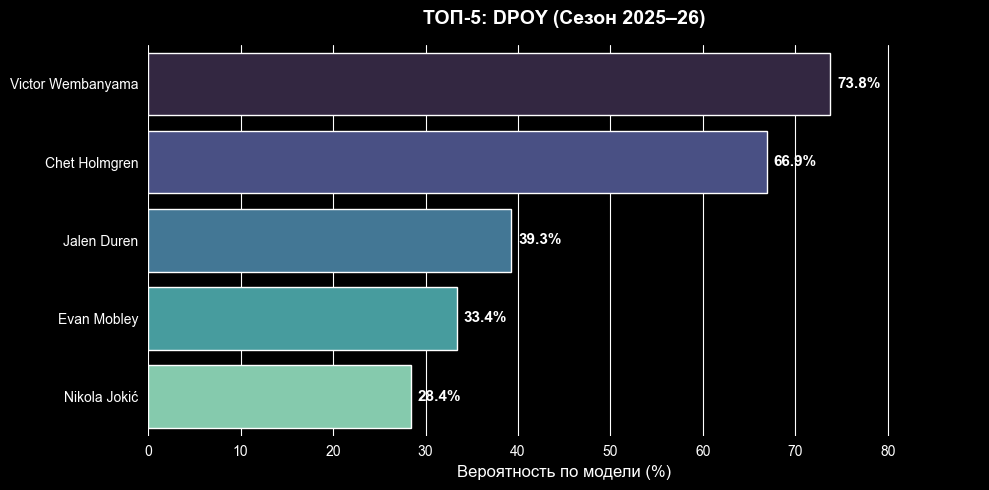


ПРОГНОЗ: MIP | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Deni Avdija,60.68
1,Nickeil Alexander-Walker,59.58
2,Lauri Markkanen,25.88
3,Ryan Rollins,21.86
4,Kevin Porter Jr.,20.89


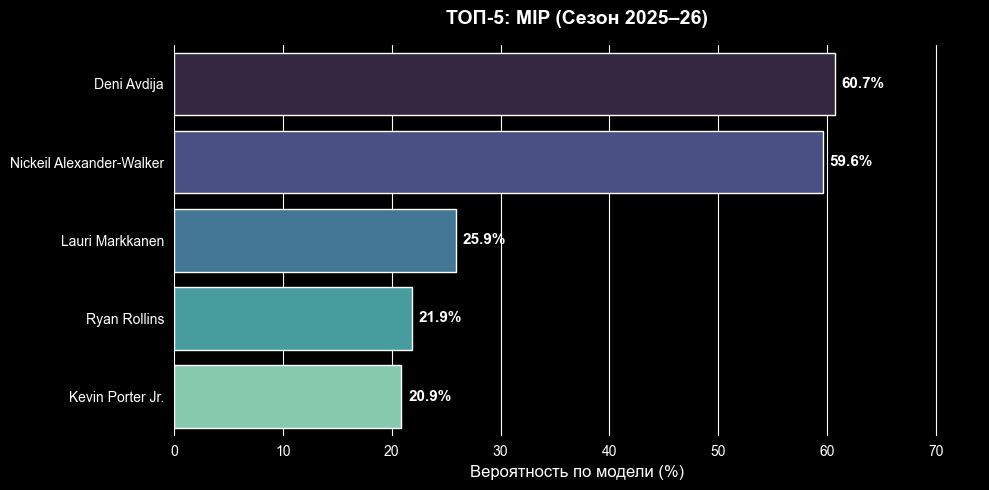


ПРОГНОЗ: ROTY | Сезон 2025–26

ТОП-5 претендентов:


,PLAYER_NAME,Шанс на победу (%)
0,Cooper Flagg,19.320000
1,VJ Edgecombe,17.629999
2,Derik Queen,3.370000
3,Dylan Harper,1.290000
4,Jeremiah Fears,1.190000


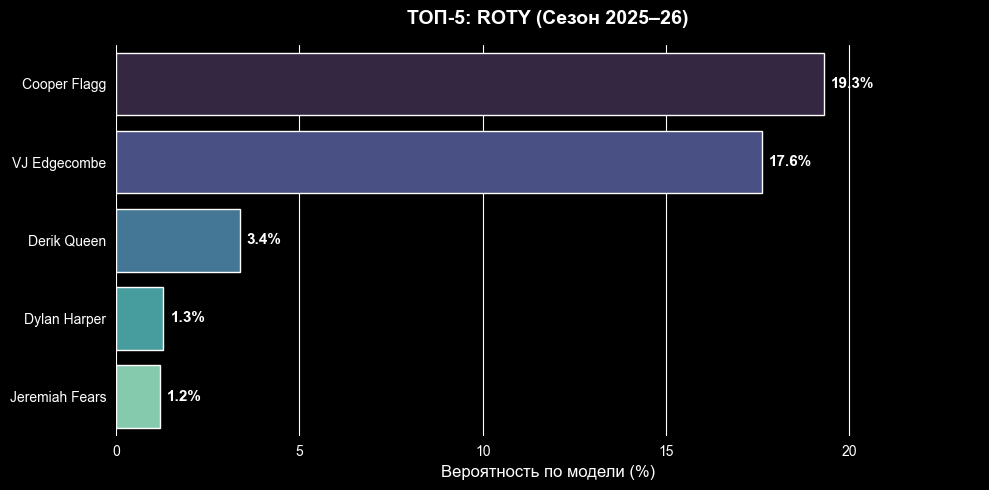

In [38]:
print("ПРОГНОЗЫ (с экспертной корректировкой):")
print("=" * 65)

predict_and_show_probabilities(
    df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    RandomForestClassifier(n_estimators=100, max_depth=5,
                           class_weight='balanced', random_state=42)
)

predict_and_show_probabilities(
    df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)

predict_and_show_probabilities(
    df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    RandomForestClassifier(n_estimators=100, max_depth=5,
                           class_weight='balanced', random_state=42)
)

predict_and_show_probabilities(
    df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5,
                           class_weight='balanced', random_state=42)
)

predict_and_show_probabilities(
    df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                  random_state=42, eval_metric='logloss')
)


,---
## Часть 7. Итоги и интерпретация результатов

### 7.1 Что было сделано — краткое резюме

| Этап | Что сделано |
|------|------------|
| **Данные** | 13 сезонов НБА (2013–26), Regular Season, ~500 игроков × сезон |
| **Инженерия признаков** | TS%, USG%, процентили, дельты, лейблы 5 наград |
| **EDA** | Анализ распределений, выбросов, корреляций, трёхочковой революции |
| **Моделирование** | 4 модели × 5 задач, TimeSeriesSplit, GridSearchCV |
| **Прогнозы** | 2 набора топ-5 претендентов на каждую награду сезона 2025–26 |

---

### 7.2 Качество моделей: ориентиры для интерпретации

**AUC-ROC:**

| Значение | Интерпретация |
|----------|--------------|
| 0.50–0.60 | Почти случайное угадывание |
| 0.60–0.75 | Умеренно хорошая |
| **0.75–0.92** | **Хороший результат** — ожидаем для MVP/Champion |
| 0.92–1.00 | Отличный, но возможно переобучение |

Для задач с сильным дисбалансом (1 победитель на 400–500 игроков) AUC в диапазоне **0.85–0.97** является нормальным результатом: победители исторически действительно резко выделялись по статистике.

**Log Loss:**  
- Значения в диапазоне **0.05–0.15** — хороший результат (модель уверенно ставит высокие вероятности истинным победителям)  
- Значения выше **0.3** — модель затрудняется

---

### 7.3 Главный результат: что получили

**Построена система, которая:**

1. По статистике регулярного сезона **ранжирует претендентов** на 5 главных наград НБА
2. Выдаёт **вероятности** (а не просто «да/нет»), что позволяет оценить уверенность прогноза
3. **Воспроизводима**: при обновлении данных (новый сезон) нужно только загрузить новый CSV и перезапустить ноутбук

**Практическая ценность:**
- Быстрое ранжирование претендентов в начале и середине сезона
- Выявление ключевых статистических «сигналов» для каждой номинации
- Основа для более сложных систем (добавление медиа-метрик, данных о травмах)

---

### 7.4 Ограничения системы

| Ограничение | Почему это важно знать |
|-------------|----------------------|
| **Только Regular Season** | Форс-мажоры в плей-офф не учитываются |
| **Нет «нарратива»** | Голосующие журналисты учитывают медиа-образ, травмы, политику лиги |
| **Малая обучающая выборка** | 11–12 примеров класса 1 — это мало для сложных моделей |
| **Частичные данные 2025–26** | Если сезон не завершён — прогноз предварительный |
| **Исторический сдвиг** | Стиль игры меняется; паттерны 2014 года слабее работают в 2026 |

---

### 7.5 Заключение

Построенный пайплайн демонстрирует, что **статистика регулярного сезона НБА является сильным предиктором индивидуальных наград**. Модели фиксируют паттерны, которые человек-аналитик может упустить при ручном анализе: например, важность `NBA_FANTASY_PTS` (интегрального рейтинга) для MVP или роль `BLK_RANK` для DPOY.

Несмотря на объективные ограничения (дисбаланс классов, «человеческий фактор» в голосовании), система даёт воспроизводимую и интерпретируемую оценку — именно это является главной ценностью аналитического инструмента.

---

*Ноутбук написан с расчётом на ежегодное обновление: при загрузке нового CSV и запуске всех ячеек по порядку получается актуальный прогноз на текущий сезон.*
